## Introduction

### Background

In natural environments, vision is an active process: animals do not passively receive visual input but continuously direct their eyes, head, and body to gather information. Unlike traditional head-fixed experiments where subjects view 2D screens, freely moving animals must stabilize their gaze during locomotion and rapidly reorient it to explore the world. 

Gaze behavior in primates consists of two fundamental modes—gaze fixation and gaze shifts—each supported by distinct sensorimotor mechanisms. Gaze fixation refers to periods when the eyes maintain a stable visual line of sight, even when the head moves. This stability is primarily achieved through the VOR, in which head rotation triggers a compensatory eye movement in the opposite direction. The result is a characteristic negative correlation between eye and head velocity: as the head drifts slightly, the eye counter-rotates to keep gaze steady. Fixation therefore provides a clean physiological signature of VOR function in freely moving animals.

In contrast, gaze shifts are rapid reorientations of gaze used to bring new objects of interest onto the fovea. In natural behavior—especially in freely moving marmosets—gaze shifts can be produced by the eyes alone or by coordinated contributions of the eyes and head. These movements fall into two main categories:

Type 1 gaze shifts (combined eye + head), in which both effectors generate meaningful movement. In these events, the eye typically peaks first, and the head reaches its peak later. As the head slows with a long tail, the eye often reverses direction briefly to re-engage the VOR and stabilize final gaze direction.

Type 2 gaze shifts (eye-only), where the eye produces a sharp, saccade-like velocity peak while the head contributes minimally.

These dynamics were illustrated vividly in the original dataset and figures (e.g., Figure 6C and 6D), where fixation shows clean VOR anti-correlation, and gaze shifts show distinct temporal coordination patterns. Such patterns represent the natural biomechanics and neural control principles of primate gaze.

Understanding how these two modes—fixation and gaze shift—interact is fundamental to modeling naturalistic eye–head coordination. In this project, the simulation aims to reproduce these biological signatures, using real marmoset data to constrain the kinematics of both fixation and gaze-shift events. The simulation’s success is evaluated by comparing real and synthetic events on peak velocities, durations, and distributional properties.

### Justification for choice of study

I chose a recent paper from my advisor and focused on replicating the analyses presented in Figure 6, with particular emphasis on Figure 6C. This figure illustrates gaze behavior in freely moving marmosets equipped with the CEREBRO head-mounted eye-tracking system. In the study, animals explored a large open arena (200 cm × 100 cm × 240 cm) while the system simultaneously recorded their eye and head movements. The aim of the experiment was to characterize how eye velocity and head velocity interact during natural behavior. CEREBRO proved to be an effective tool for collecting high-quality eye-tracking data in unrestrained marmosets, making it highly relevant to my own work.

In my project, I will also use CEREBRO to record data from freely moving animals, particularly in tasks involving natural behaviors such as social interactions. My research centers on understanding the visual behavior of marmosets in ecological contexts, so becoming familiar with the structure, characteristics, and limitations of CEREBRO-based eye-tracking data is essential for pursuing my future research questions.


### Links

Project repository (on Github): https://github.com/Luyiheng-19/singh2025active/tree/main

Original paper (as hosted in your repo): https://github.com/Luyiheng-19/singh2025active/blob/main/original_paper/2025_SinghEtAl.pdf

### Key Reproducibility Criteria

H1. Fixation Periods Negative Correlation and Gaze-Shift Periods Weak Correlation 

During fixation periods (non–gaze-shift epochs), the simulated eye and head velocity should show a negative correlation, reflecting the vestibulo-ocular reflex (VOR).

The simulation should not produce strong positive or negative correlations during gaze-shift periods. This pattern should resemble the VOR structure shown in Figure 6C of the original paper.

H2. Presence of Two Distinct Gaze-Shift Events

The simulated 10-second interval should contain two clear gaze-shift events, matching the example shown in Figure 6D (bottom) of the original paper.

H2.1 Event 1: Combined Head + Eye Gaze Shift with VOR Re-engagement

In the first simulated event, both eye and head velocities should change, reflecting a combined (Type 1) shift. This event should exhibit a characteristic temporal sequence. First, the eye velocity reaches its peak. The head velocity peak follows with a delay and decays more slowly, creating a long tail. As the head continues its gradual decline, the eye velocity crosses zero and reverses direction, marking the re-engagement of the VOR to stabilize gaze. In the simulated traces, this produces an early eye peak, a later head peak, and a subsequent eye reversal when the head velocity remains positive—matching the coordination pattern observed in the original dataset.

H2.2 Event 2: Eye-Dominated Gaze Shift

In the second simulated event, the gaze velocity profile should primarily follow the eye velocity, with minimal contribution from head movement.

H3.  Matched Kinematic Statistics

For both simulated events, peak velocity and event duration should be similar to the corresponding events detected in the random 10-second real interval.




## Methods

### Description of the steps required to reproduce the results

The preprocessed data(it is on https://datadryad.org/dataset/doi:10.5061/dryad.8gtht76xb) is avalible. Firstly we should load data and randomly choose the 10s interval, which should have two velocities with negative relation. Secondly we should detect the gaze shift event1 and event2 during this event and calculate its related parameters. Then we should simulate the fixation data, event1 pulse, event2 pulse and random pulse. Next we visulaize and do correlation analysis like origin paper. Then we do t-test to compare the event-level statistics between real data and simulated data to justify the similarity between two datasets. Finially we do some exploring analysis to evaluate our simulation method, to further justify the simulation method or question some assumptions in the simulation process.



### Differences from original study


The original study collect data in real head free marmosets and analysis its eye and head behavior. My study is a simulation method, so the data is generated based on the findings in original study. It is impossible to capture all the features of head and eye velocity in the real world so the data is different and simplier than the orginal paper. But it reporduces some the findings in orginal data.

Additionally, I added some statistical analysis to justify the similarity between real data and simulated data. These analysis are not in original paper. Also, I use event detection method in real data to do more exploratory event-level analysis.



### Measure of success

H1: The simulation successfully reproduces the expected correlation patterns. During fixation, eye and head velocities show a strong negative correlation (e.g., r ≈ –0.6), whereas during gaze shifts the correlation becomes weak or near zero (e.g., r ≈ -0.2 to 0.2). These values fall within the range observed in the real dataset, indicating that the correlation structure is faithfully captured.

H2: The simulated gaze-shift events also capture the characteristic temporal dynamics observed in the real data. For Event 1, the eye velocity peaks first, followed by a delayed head velocity peak with a long tail. The eye velocity then reverses direction as the head decays, demonstrating VOR re-engagement. For Event 2, the eye velocity dominates the gaze shift with minimal head contribution. 

H3: The key event-level parameters—such as event duration and peak eye/head velocities—are statistically comparable to the real dataset. Independent-samples t-tests typically show no significant differences (p > 0.05) between simulated and real events, and effect sizes (Cohen’s d) remain small, confirming that the simulated distributions align well with empirical measurements.


### Data wrangling/model construction


#### Load data and Data Wrangling

The raw dataset is imported from preprocessed NumPy arrays that contain synchronized head and eye velocity measurements across the full recording session. These arrays include:

Vhead — head rotational velocity (deg/s)

Veye — eye rotational velocity (deg/s)

eye_time_sel — timestamps of each sample

These signals come from freely moving marmoset experiments using head-mounted eye tracking and provide the empirical basis for both event detection and statistical extraction.

Once imported, the notebook checks array shapes, NaN values, and sampling rate consistency to ensure the data is suitable for downstream event segmentation. Additionally, it calulate the stats of real data

In [6]:
import os

# List all files in current folder
print(os.listdir())


['Untitled1-Copy4.ipynb', 'Untitled1.ipynb', 'Final-Copy1.ipynb', 'Untitled1-Copy2.ipynb', 'Untitled.ipynb', 'Untitled1-Copy5.ipynb', 'Final-Copy2.ipynb', 'Untitled1-Copy1.ipynb', 'Untitled1-Copy3.ipynb', 'README.md', 'Final.ipynb', 'Head_Eye_Body_Movement_Data_VPS_2024.mat', '.ipynb_checkpoints']


In [ ]:
from scipy.io import loadmat

# Load the .mat file

data = loadmat('Head_Eye_Body_Movement_Data_VPS_2024.mat')
print(data.keys())



dict_keys(['__header__', '__version__', '__globals__', 'Syncbox', 'eye_deg', 'eye_degV', 'eye_isSac_chair', 'eye_isSac_free', 'eye_time', 'fs_eye', 'fs_opti', 'opti_bodySmoV', 'opti_bodyxyz_smo', 'opti_headrot_smo', 'opti_headuvwSmoV', 'opti_headuvw_smo', 'opti_isHdt', 'opti_isLoc', 'opti_time', 'opti_timeDelay', 'opti_timeIR', 't'])


In [ ]:
# Print variable names and their types/shapes

for key, value in data.items():
    if not key.startswith('__'):  # skip internal stuff
        print(f"\n🔹 Variable name: {key}")
        if hasattr(value, 'shape'):
            print(f"  Shape: {value.shape}")
        print(f"  Type: {type(value)}")
        
        # Show a small preview
        try:
            print("  Sample data:", value[:5])  # first 5 rows
        except Exception as e:
            print("  (Cannot preview, maybe not a simple array)")



🔹 Variable name: Syncbox
  Shape: (1, 1)
  Type: <class 'numpy.ndarray'>
  Sample data: [[(array([[302.4]]), array([[100.809]]), array([[187.917]]), array([[218.792]]), array([[237.018]]), array([[566.832]]), array([[662.85]]), array([[776.723]]), array([[810.262]]), array([[2669.432]]))]]

🔹 Variable name: eye_deg
  Shape: (500903, 2)
  Type: <class 'numpy.ndarray'>
  Sample data: [[-5.13192315 13.89264314]
 [-5.17600639 13.91197054]
 [-5.22008963 13.93129795]
 [-4.94702239 13.38509974]
 [-4.12243184 11.89326587]]

🔹 Variable name: eye_degV
  Shape: (500903, 1)
  Type: <class 'numpy.ndarray'>
  Sample data: [[  9.62679725]
 [  9.62679725]
 [122.1307831 ]
 [340.9115944 ]
 [669.28216051]]

🔹 Variable name: eye_isSac_chair
  Shape: (500903, 1)
  Type: <class 'numpy.ndarray'>
  Sample data: [[1]
 [1]
 [1]
 [1]
 [1]]

🔹 Variable name: eye_isSac_free
  Shape: (500903, 1)
  Type: <class 'numpy.ndarray'>
  Sample data: [[0]
 [0]
 [0]
 [0]
 [0]]

🔹 Variable name: eye_time
  Shape: (500903, 1)

Using time window: 776.723 – 2576.723 s
Samples in window: 357232


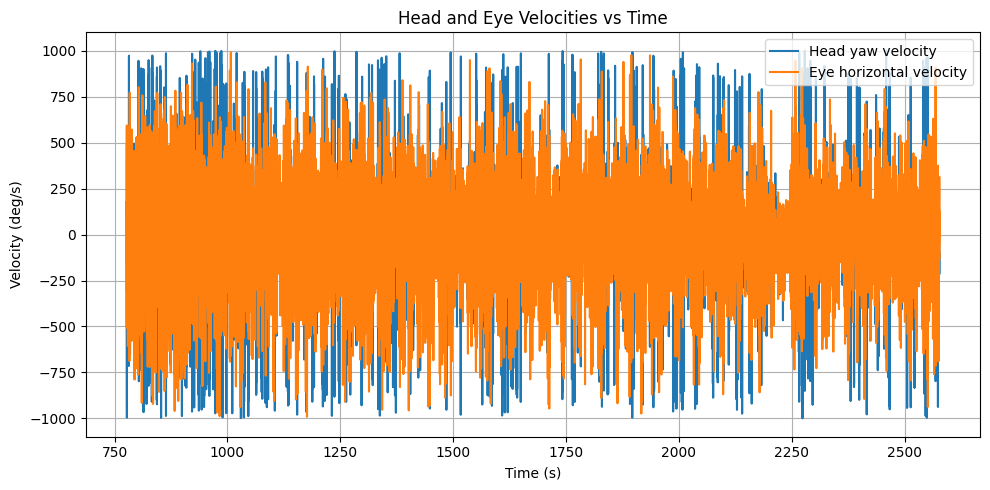

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ---  Extract data ---
eye_time = data['eye_time'].squeeze()
eye_pos = data['eye_deg'][:, 0]  # horizontal eye position (deg)
eye_is_free = data['eye_isSac_free'].squeeze().astype(bool)  # logical mask

opti_time = data['opti_time'].squeeze()
head_yaw = data['opti_headrot_smo'][:, 0]  # yaw (deg)

# --- Compute velocities (deg/s) ---
eye_hor_vel_full = np.gradient(eye_pos, eye_time)
head_yaw_vel = np.gradient(head_yaw, opti_time)

# --- 3Interpolate head velocity to eye timestamps ---
interp_head_yaw_vel = interp1d(
    opti_time, head_yaw_vel,
    bounds_error=False, fill_value="extrapolate"
)
head_yaw_vel_resampled_full = interp_head_yaw_vel(eye_time)

# --- Get time window from data['t'] 4th column ---
t_start, t_end = data['t'][3, 0], data['t'][3, 1] 
print(f"Using time window: {t_start:.3f} – {t_end:.3f} s")

# Create a mask for the time window
time_mask = (eye_time >= t_start) & (eye_time <= t_end)

free_mask = (
    np.isfinite(eye_hor_vel_full)
    & np.isfinite(head_yaw_vel_resampled_full)
    & (np.abs(head_yaw_vel_resampled_full) <= 1000)
    & (np.abs(eye_hor_vel_full) <= 1000)
    & time_mask
)

# Apply mask
eye_time_sel = eye_time[free_mask]
eye_hor_vel_sel = eye_hor_vel_full[free_mask]
head_yaw_vel_sel = head_yaw_vel_resampled_full[free_mask]

print(f"Samples in window: {np.sum(free_mask)}")

# --- Plot time series data---
plt.figure(figsize=(10, 5))
plt.plot(eye_time_sel, head_yaw_vel_sel, label='Head yaw velocity', color='tab:blue')
plt.plot(eye_time_sel, eye_hor_vel_sel, label='Eye horizontal velocity', color='tab:orange')

plt.xlabel('Time (s)')
plt.ylabel('Velocity (deg/s)')
plt.title('Head and Eye Velocities vs Time')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()




Random seed used: 1763058353
Random 10-s window: 779.350 – 789.350 s
Correlation results:
Fixation: r = -0.646
Gaze shift: r = -0.066


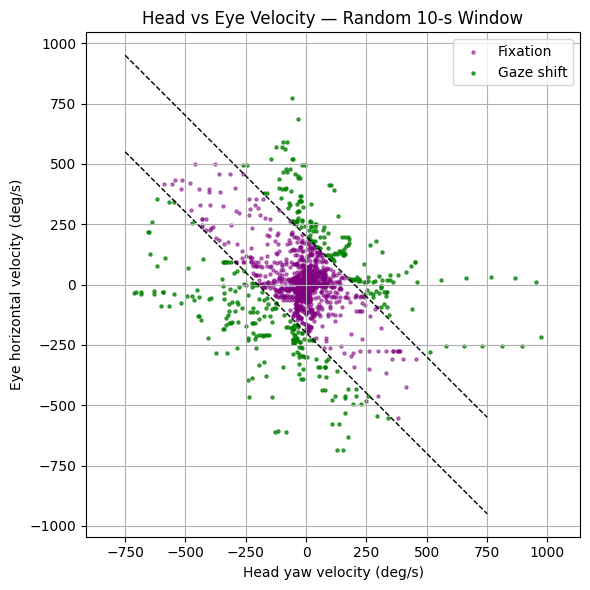

In [ ]:
import random
from scipy.stats import pearsonr

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import time

# --- Choose and log a seed ---

seed = 1763058353
print(f"Random seed used: {seed}")

rng = np.random.default_rng(seed)  # independent, local RNG

# ---  Randomly select a 10-second window within selected time range ---
window_duration = 10.0
valid_start = t_start
valid_end = t_end - window_duration

rand_start = rng.uniform(valid_start, valid_end)  # use rng, not random.uniform
rand_end   = rand_start + window_duration

print(f"Random 10-s window: {rand_start:.3f} – {rand_end:.3f} s")

# Create mask for that 10-s interval
rand_mask = (eye_time_sel >= rand_start) & (eye_time_sel <= rand_end)
# ---  Detect gaze shifts & fixations within random 10-s window ---
gaze_vel_rand = head_yaw_vel_sel[rand_mask] + eye_hor_vel_sel[rand_mask]
is_shift = np.abs(gaze_vel_rand) > 200   # gaze shift threshold
is_fix = ~is_shift                       # fixation (complement)



# --- Extract velocity pairs for each condition ---
head_fix = head_yaw_vel_sel[rand_mask][is_fix]
eye_fix = eye_hor_vel_sel[rand_mask][is_fix]
head_shift = head_yaw_vel_sel[rand_mask][is_shift]
eye_shift = eye_hor_vel_sel[rand_mask][is_shift]

# --- Calculate Pearson correlation (r) and p-value ---
r_fix, p_fix = pearsonr(head_fix, eye_fix)
r_shift, p_shift = pearsonr(head_shift, eye_shift)

# --- Print results ---
print("Correlation results:")
print(f"Fixation: r = {r_fix:.3f}")
print(f"Gaze shift: r = {r_shift:.3f}")


# ---  Scatter plot: head vs eye velocity, colored by type ---
plt.figure(figsize=(6, 6))
plt.scatter(
    head_yaw_vel_sel[rand_mask][is_fix],
    eye_hor_vel_sel[rand_mask][is_fix],
    s=5, color='purple', alpha=0.5, label='Fixation'
)
plt.scatter(
    head_yaw_vel_sel[rand_mask][is_shift],
    eye_hor_vel_sel[rand_mask][is_shift],
    s=5, color='green', alpha=0.7, label='Gaze shift'
)

# Reference lines (±1 slope)
x = np.linspace(-750, 750, 200)
plt.plot(x, -200-x, 'k--', linewidth=1)
plt.plot(x, 200-x, 'k--', linewidth=1)

plt.xlabel('Head yaw velocity (deg/s)')
plt.ylabel('Eye horizontal velocity (deg/s)')
plt.title('Head vs Eye Velocity — Random 10-s Window')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# ==============================================================
#  FIXATION STATS
# ==============================================================
is_shift = np.abs(gaze_vel_rand) > 200   # gaze shift threshold
is_fix = ~is_shift                       # fixation (complement)
head_fix = head_yaw_vel_sel[rand_mask][is_fix]
eye_fix = eye_hor_vel_sel[rand_mask][is_fix]

mean_head_fix = np.mean(head_fix)
std_head_fix = np.std(head_fix)
var_head_fix = np.var(head_fix)

mean_eye_fix = np.mean(eye_fix)
std_eye_fix = np.std(eye_fix)
var_eye_fix = np.var(eye_fix)

# Absolute values
abs_mean_head_fix = np.mean(np.abs(head_fix))
abs_std_head_fix = np.std(np.abs(head_fix))
abs_var_head_fix = np.var(np.abs(head_fix))

abs_mean_eye_fix = np.mean(np.abs(eye_fix))
abs_std_eye_fix = np.std(np.abs(eye_fix))
abs_var_eye_fix = np.var(np.abs(eye_fix))

# Regression
slope_fix, intercept_fix, r_fix, p_fix, stderr_fix = linregress(head_fix, eye_fix)

print("=== FIXATION ===")
print(f"Head mean={mean_head_fix:.2f}, std={std_head_fix:.2f}, var={var_head_fix:.2f}")
print(f"Eye  mean={mean_eye_fix:.2f}, std={std_eye_fix:.2f}, var={var_eye_fix:.2f}")
print(f"|Head| mean={abs_mean_head_fix:.2f}, std={abs_std_head_fix:.2f}, var={abs_var_head_fix:.2f}")
print(f"|Eye|  mean={abs_mean_eye_fix:.2f}, std={abs_std_eye_fix:.2f}, var={abs_var_eye_fix:.2f}")
print(f"Regression slope (eye~head): {slope_fix:.3f}, r={r_fix:.3f}, p={p_fix:.3e}")

# ==============================================================
#  GAZE SHIFT STATS (same logic as fixation)
# ==============================================================

# Define gaze shift using summed velocity
gaze_sum = head_yaw_vel_sel[rand_mask] + eye_hor_vel_sel[rand_mask]
is_shift2 = np.abs(gaze_sum) > 200    # new definition
shift_head = head_yaw_vel_sel[rand_mask][is_shift2]
shift_eye  = eye_hor_vel_sel[rand_mask][is_shift2]

# ---- Mean / Std / Var ----
mean_head_shift = np.mean(shift_head)
std_head_shift  = np.std(shift_head)
var_head_shift  = np.var(shift_head)

mean_eye_shift = np.mean(shift_eye)
std_eye_shift  = np.std(shift_eye)
var_eye_shift  = np.var(shift_eye)

# ---- Absolute values ----
abs_mean_head_shift = np.mean(np.abs(shift_head))
abs_std_head_shift  = np.std(np.abs(shift_head))
abs_var_head_shift  = np.var(np.abs(shift_head))

abs_mean_eye_shift = np.mean(np.abs(shift_eye))
abs_std_eye_shift  = np.std(np.abs(shift_eye))
abs_var_eye_shift  = np.var(np.abs(shift_eye))

# ---- Regression eye ~ head ----
slope_shift, intercept_shift, r_shift, p_shift, stderr_shift = linregress(shift_head, shift_eye)

print("=== GAZE SHIFT (Vhead + Veye > 200) ===")
print(f"Head mean={mean_head_shift:.2f}, std={std_head_shift:.2f}, var={var_head_shift:.2f}")
print(f"Eye  mean={mean_eye_shift:.2f}, std={std_eye_shift:.2f}, var={var_eye_shift:.2f}")
print(f"|Head| mean={abs_mean_head_shift:.2f}, std={abs_std_head_shift:.2f}, var={abs_var_head_shift:.2f}")
print(f"|Eye|  mean={abs_mean_eye_shift:.2f}, std={abs_std_eye_shift:.2f}, var={abs_var_eye_shift:.2f}")
print(f"Regression slope (eye~head): {slope_shift:.3f}, r={r_shift:.3f}, p={p_shift:.3e}")




=== FIXATION ===
Head mean=-10.42, std=96.72, var=9354.68
Eye  mean=4.11, std=93.39, var=8721.08
|Head| mean=51.08, std=82.79, var=6853.69
|Eye|  mean=54.52, std=75.93, var=5765.11
Regression slope (eye~head): -0.624, r=-0.646, p=1.287e-189
=== GAZE SHIFT (Vhead + Veye > 200) ===
Head mean=-32.88, std=275.44, var=75869.79
Eye  mean=-17.47, std=266.89, var=71232.37
|Head| mean=205.04, std=186.84, var=34911.01
|Eye|  mean=215.03, std=159.05, var=25297.97
Regression slope (eye~head): -0.064, r=-0.066, p=1.901e-01


### Event Detection Moldel Construction

Event 1 (head-driven):

$|V_{\text{head}}(t)| > 200 \ \text{deg/s}$

Event 2 (eye-only, not inside Event 1):

$|V_{\text{eye}}(t)| > 200 \ \text{deg/s}$

This marks candidate gaze-shift intervals.
Construct continuous event windows:
Consecutive samples above threshold are grouped into events. I then applies padding (−1 to +1 samples) to ensure the full head/eye dynamics around the event are captured.
Store event boundaries as a list of (start_idx, end_idx) pairs.
Event metrics extracted per event include:
Peak head velocity
Peak eye velocity
Event duration (ms or samples)
Underlying fixation interval lengths
These event measurements form the empirical statistical basis for the simulation model. Later, real-event distributions are compared to simulated ones to validate the generative pipeline.

Sampling rate ≈ 200.0 Hz


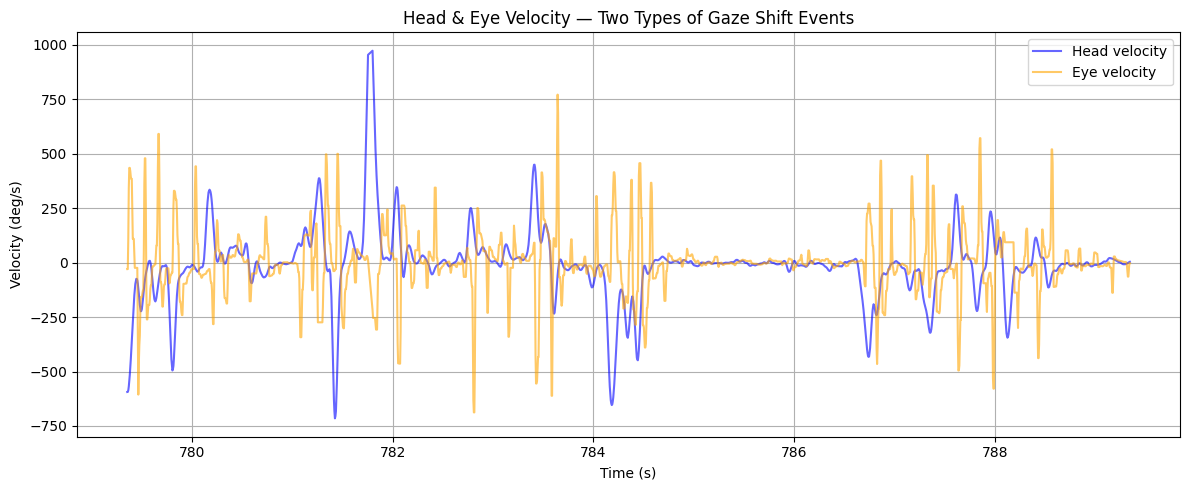

In [12]:
# ==============================================================
# 🔹 Basic variables
# ==============================================================
time = eye_time_sel[rand_mask]
Vhead = head_yaw_vel_sel[rand_mask]
Veye  = eye_hor_vel_sel[rand_mask]

n = len(time)
fs_est = 1 / np.median(np.diff(time))  # approximate sampling rate
print(f"Sampling rate ≈ {fs_est:.1f} Hz")



# ==============================================================
# 🔹 Plot results
# ==============================================================

plt.figure(figsize=(12, 5))
plt.plot(time, Vhead, label='Head velocity', color='blue', alpha=0.6)
plt.plot(time, Veye,  label='Eye velocity',  color='orange', alpha=0.6)


plt.xlabel("Time (s)")
plt.ylabel("Velocity (deg/s)")
plt.title("Head & Eye Velocity — Two Types of Gaze Shift Events")
plt.legend(loc='upper right', frameon=True)
plt.grid(True)
plt.tight_layout()
plt.show()



Detected Event1 segments (extended):
(0, 14)
(25, 31)
(83, 99)
(157, 172)
(372, 391)
(407, 424)
(471, 496)
(523, 536)
(673, 682)
(795, 813)
(840, 847)
(947, 973)
(983, 997)
(1001, 1018)
(1459, 1481)
(1481, 1491)
(1582, 1601)
(1640, 1651)
(1683, 1690)
(1710, 1718)
(1741, 1755)


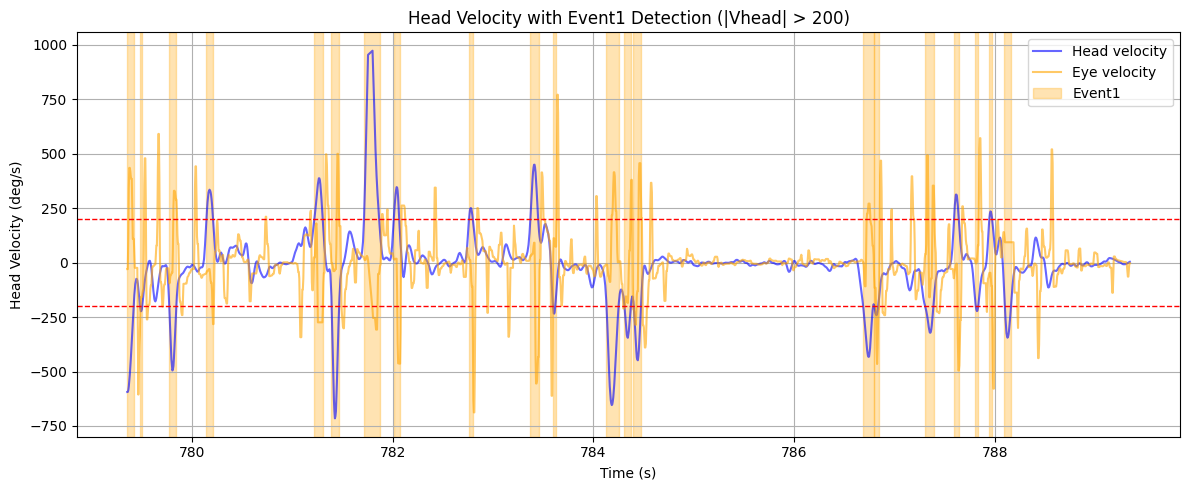

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------------------
# 1. Detect Event1 (|Vhead| > 200) with 1-point extension
# --------------------------------------------------------------
time = eye_time_sel[rand_mask]
thr = 200
mask = (Vhead > thr) | (Vhead < -thr)   # boolean mask

event1 = []
start = None

for i, val in enumerate(mask):
    if val:
        if start is None:
            start = i
    else:
        if start is not None:
            end = i
            # Add 1 sample padding on both sides
            s_ext = max(start - 1, 0)
            e_ext = min(end + 1, len(mask))
            event1.append((s_ext, e_ext))
            start = None

# Catch event that goes to the end
if start is not None:
    s_ext = max(start - 1, 0)
    e_ext = len(mask)
    event1.append((s_ext, e_ext))

print("Detected Event1 segments (extended):")
for ev in event1:
    print(ev)

# --------------------------------------------------------------
# 2. Plot original figure + threshold + event intervals
# --------------------------------------------------------------

plt.figure(figsize=(12, 5))

plt.plot(time, Vhead, label='Head velocity', color='blue', alpha=0.6)
plt.plot(time, Veye,  label='Eye velocity',  color='orange', alpha=0.6)

# ±200 threshold lines
plt.axhline(thr, color='red', linestyle='--', linewidth=1)
plt.axhline(-thr, color='red', linestyle='--', linewidth=1)

# Highlight Event1 segments
for (s, e) in event1:
    plt.axvspan(time[s], time[e-1], color='orange', alpha=0.3, label="Event1" if 'Event1' not in plt.gca().get_legend_handles_labels()[1] else None)

plt.xlabel("Time (s)")
plt.ylabel("Head Velocity (deg/s)")
plt.title("Head Velocity with Event1 Detection (|Vhead| > 200)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


=== Event2 (|Vhead| > 200 but not Event1) ===
(20, 25)
(33, 39)
(38, 43)
(60, 66)
(69, 73)
(99, 101)
(107, 112)
(134, 140)
(172, 174)
(275, 279)
(343, 350)
(364, 368)
(394, 403)
(427, 435)
(499, 504)
(509, 513)
(536, 539)
(538, 548)
(604, 609)
(682, 687)
(689, 694)
(709, 713)
(751, 756)
(813, 815)
(816, 823)
(836, 840)
(847, 854)
(926, 931)
(980, 983)
(997, 1001)
(1018, 1020)
(1019, 1031)
(1034, 1040)
(1491, 1493)
(1492, 1498)
(1497, 1505)
(1515, 1518)
(1554, 1561)
(1601, 1603)
(1605, 1614)
(1651, 1656)
(1656, 1661)
(1690, 1696)
(1705, 1708)
(1718, 1723)
(1766, 1770)
(1806, 1813)
(1833, 1839)


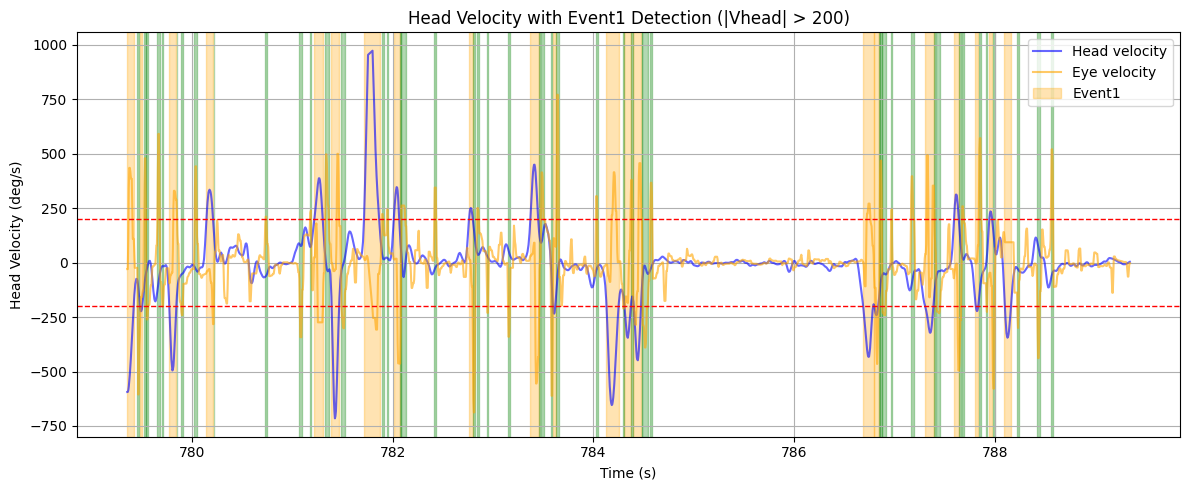

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Build mask for extended Event1
thr1 = 100
mask1 = (Vhead > thr1) | (Vhead < -thr1)
event1_mask = np.zeros_like(mask1, dtype=bool)
for s, e in event1:
    event1_mask[s:e] = True


# ==============================================================
# 2. Event2 detection: NOT in Event1 & |eye| > 200
# ==============================================================

thr2 = 200
mask2_base = (np.abs(Veye) > thr2) & (~event1_mask)

event2 = []
start = None

for i, val in enumerate(mask2_base):
    if val:
        if start is None:
            start = i
    else:
        if start is not None:
            end = i
            # extend by 1 sample
            s_ext = max(start - 1, 0)
            e_ext = min(end + 1, len(mask2_base))

            # ensure no overlap with Event1 after extension
            while s_ext < e_ext and event1_mask[s_ext]:
                s_ext += 1
            while e_ext > s_ext and event1_mask[e_ext - 1]:
                e_ext -= 1

            if s_ext < e_ext:
                event2.append((s_ext, e_ext))

            start = None

# catch event at tail
if start is not None:
    s_ext = max(start - 1, 0)
    e_ext = len(mask2_base)

    while s_ext < e_ext and event1_mask[s_ext]:
        s_ext += 1
    while e_ext > s_ext and event1_mask[e_ext - 1]:
        e_ext -= 1

    if s_ext < e_ext:
        event2.append((s_ext, e_ext))

print("=== Event2 (|Vhead| > 200 but not Event1) ===")
for ev in event2:
    print(ev)




# 3. Plot Event1 and Event2 on original trace
# ==============================================================

plt.figure(figsize=(12, 5))

plt.plot(time, Vhead, label='Head velocity', color='blue', alpha=0.6)
plt.plot(time, Veye,  label='Eye velocity',  color='orange', alpha=0.6)

# ±200 threshold lines
plt.axhline(thr2, color='red', linestyle='--', linewidth=1)
plt.axhline(-thr2, color='red', linestyle='--', linewidth=1)

# Highlight Event1 segments
for (s, e) in event1:
    plt.axvspan(time[s], time[e-1], color='orange', alpha=0.3, label="Event1" if 'Event1' not in plt.gca().get_legend_handles_labels()[1] else None)

for (s, e) in event2:
    plt.axvspan(time[s], time[e-1], color='green', alpha=0.3, label="Event1" if 'Event1' not in plt.gca().get_legend_handles_labels()[1] else None)


plt.xlabel("Time (s)")
plt.ylabel("Head Velocity (deg/s)")
plt.title("Head Velocity with Event1 Detection (|Vhead| > 200)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()




In [ ]:

# ===========================================================
# extract event stats
# ===========================================================

fs = 200  # Hz

def compute_head_eye_event_stats(events, Vhead, Veye, fs):
    """
    For each event (s, e), compute:
      - peak |Vhead|
      - peak |Veye|
      - duration (sec)
    Then return mean/std for each, plus n_events.
    """
    if not events:
        return {
            "head_peak_mean": np.nan,
            "head_peak_std":  np.nan,
            "eye_peak_mean":  np.nan,
            "eye_peak_std":   np.nan,
            "dur_mean":       np.nan,
            "dur_std":        np.nan,
            "n_events":       0,
        }

    head_peaks = []
    eye_peaks  = []
    durations  = []

    for (s, e) in events:
        seg_head = Vhead[s:e]
        seg_eye  = Veye[s:e]
        if len(seg_head) == 0 or len(seg_eye) == 0:
            continue

        # absolute peak amplitudes
        head_peaks.append(np.max(np.abs(seg_head)))
        eye_peaks.append(np.max(np.abs(seg_eye)))

        # duration in seconds
        durations.append((e - s) / fs)

    if len(head_peaks) == 0:
        return {
            "head_peak_mean": np.nan,
            "head_peak_std":  np.nan,
            "eye_peak_mean":  np.nan,
            "eye_peak_std":   np.nan,
            "dur_mean":       np.nan,
            "dur_std":        np.nan,
            "n_events":       0,
        }

    head_peaks = np.array(head_peaks)
    eye_peaks  = np.array(eye_peaks)
    durations  = np.array(durations)

    return {
        "head_peak_mean": float(np.mean(head_peaks)),
        "head_peak_std":  float(np.std(head_peaks)),
        "eye_peak_mean":  float(np.mean(eye_peaks)),
        "eye_peak_std":   float(np.std(eye_peaks)),
        "dur_mean":       float(np.mean(durations)),
        "dur_std":        float(np.std(durations)),
        "n_events":       int(len(durations)),
    }

# ----------------------------------------------------------
# Stats for Event1 and Event2
# ----------------------------------------------------------
stats_type1 = compute_head_eye_event_stats(event1, Vhead, Veye, fs)
stats_type2 = compute_head_eye_event_stats(event2, Vhead, Veye, fs)

print("=== stats_type1 (Event1) ===")
for k, v in stats_type1.items():
    print(f"{k}: {v}")

print("\n=== stats_type2 (Event2) ===")
for k, v in stats_type2.items():
    print(f"{k}: {v}")


=== stats_type1 (Event1) ===
head_peak_mean: 407.6822951369742
head_peak_std: 187.08107240202258
eye_peak_mean: 359.42385757295875
eye_peak_std: 120.57754729693184
dur_mean: 0.07309523809523809
dur_std: 0.02800834018969003
n_events: 21

=== stats_type2 (Event2) ===
head_peak_mean: 94.59752061270642
head_peak_std: 52.08875993451791
eye_peak_mean: 360.55337020604543
eye_peak_std: 144.9421015767753
dur_mean: 0.025937500000000002
dur_std: 0.010880805442766327
n_events: 48


### Simulation Model Construction


The simulation model reconstructs head and eye velocity signals by combining three components:
(1) fixation baseline dynamics, (2) gaze-shift events, and (3) small random pulses that mimic natural micro-movements.
The goal is to reproduce key properties observed in freely moving marmosets, including VOR-like eye–head coupling during fixation and realistic temporal structure of gaze shifts.

1. Fixation Model

During fixation, head velocity follows a slow sinusoidal pattern reflecting small natural body sway:

Head baseline:

$V_{\text{head,fix}}(t) = A_{\text{fix}}\sin(2\pi f_{\text{fix}} t)$

Eye fixation is modeled as a VOR-driven counter-rotation proportional to head velocity:

Eye baseline:

$V_{\text{eye,fix}}(t) = r \cdot V_{\text{head,fix}}(t)$

This creates a strong negative correlation between eye and head velocities, matching the VOR band seen in real data.

2. Event 2 (Eye-Only Gaze Shift)

Event 2 represents sharp, fast eye movements where the head stays near baseline.
Each event samples a duration and peak amplitude from empirical distributions:

Duration:

$D_k \sim \mathcal{N}(\mu_{D,2}, \sigma_{D,2}^2)$

Peak eye velocity:
$A^{\text{eye}}k \sim \mathcal{N}(\mu{\text{eye},2}, \sigma_{\text{eye},2}^2)$

The eye velocity is modeled as a half-sine pulse:

$V^{(k)}_{\text{eye}}(t) = s_k A^{\text{eye}}_k \sin\left(\frac{\pi t}{D_k}\right)$


The head does not contribute:

$V^{(k)}_{\text{head}}(t) = 0$

This creates rapid, isolated eye bursts similar to the eye-only events in the real dataset.

3. Event 1 (Combined Eye + Head Gaze Shift)

Event 1 models full gaze shifts that involve coordinated eye and head motion.
The eye moves first with a short, fast burst, while the head follows with a delayed, longer movement.
Durations and onset delay:

$D_{\text{eye}} = 0.60D_k$,

$D_{\text{head}} = 1.10D_k$,

$\delta_k = 0.10D_k$

Eye pulse (initiates the shift):

$V^{(k)}_{\text{eye,core}}(t) = s_k A^{\text{eye}}k \sin\left(\frac{\pi t}{D{\text{eye}}}\right)$

Head pulse (delayed and broader):

$V^{(k)}_{\text{head,core}}(t) = s_k A^{\text{head}}k \sin\left(\frac{\pi(t - \delta_k)}{D{\text{head}}}\right)$

After the head peaks, a late VOR component appears to stabilize gaze:
Late VOR:

$V^{(k)}_{\text{eye,VOR}}(t) = s_k A^{\text{VOR}}k \sin\left(\frac{\pi t}{D{\text{head}}}\right)$

Final event velocities:

$V^{(k)}{\text{head,event}} = V^{(k)}{\text{head,core}}$

$V^{(k)}{\text{eye,event}} = V^{(k)}{\text{eye,core}} - V^{(k)}_{\text{eye,VOR}}$

This reproduces known gaze-shift dynamics: rapid eye initiation, slower head turn, and late VOR compensation.

4. Random Fixation Pulses
To capture irregular small movements seen during natural behavior, random short pulses are added during fixation:

Head pulse:

$V^{(k)}_{\text{head,rand}}(t) = s_k A^{\text{pulse}}_k \sin\left(\frac{\pi t}{D_k}\right)$

Eye pulse coupled via VOR:

$V^{(k)}{\text{eye,rand}}(t) = r{\text{VOR}} \cdot V^{(k)}_{\text{head,rand}}(t)$

These pulses generate micro-fluctuations so the fixation periods look realistic rather than perfectly smooth.

5. Final Reconstructed Simulation
The final head and eye velocity traces combine fixation, event-driven pulses, and random activity:

Head:

$V_{\text{head,sim}} = V_{\text{head,fix}} + \sum_k V^{(k)}{\text{head,event}} + \sum_k V^{(k)}{\text{head,rand}}$

Eye:

$V_{\text{eye,sim}} = V_{\text{eye,fix}} + \sum_k V^{(k)}{\text{eye,event}} + \sum_k V^{(k)}{\text{eye,rand}}$

This produces a continuous time series whose statistical and temporal structure closely matches the original freely moving marmoset dataset.





In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

import time

# --- Generate and log a seed ---
print(f"Random seed used: {seed}")
np.random.seed(seed)


# --- 1. Time vector ---
fs = 200          # Hz
dt = 1/fs
T = 10.0
time = np.arange(0, T, dt)
n_samples = len(time)

# --- 2. Fixation baseline ---
A_head_fix = 10
A_eye_fix  = 10
r = slope_fix
f_fix = 0.5  # Hz


# Noise std = sqrt(var_data - var_sin)
noise_std_head_fix = 5
noise_std_eye_fix  = 5

# Generate fixation baseline
Vhead_fix = A_head_fix * np.sin(2*np.pi*f_fix*time) 
Veye_fix  = r * Vhead_fix

# ==============================================================
#  Create event1 and event2 from stats_type1 and stats_type2
# ==============================================================



fs_est = fs  # use actual sampling rate

# --- Targets (how many events we want to simulate) ---

if stats_type1 is not None:
    n_events1_target = int(stats_type1.get('n_events', 0))   # event1 ← stats_type2
    mean_dur1 = float(stats_type1.get('dur_mean', 0.0))      # seconds
    std_dur1  = float(stats_type1.get('dur_std',  0.0))      # seconds
else:
    n_events1_target = 0
    mean_dur1 = 0.0
    std_dur1  = 0.0

if stats_type2 is not None:
    n_events2_target = int(stats_type2.get('n_events', 0))   # event2 ← stats_type1
    mean_dur2 = float(stats_type2.get('dur_mean', 0.0))
    std_dur2  = float(stats_type2.get('dur_std',  0.0))
else:
    n_events2_target = 0
    mean_dur2 = 0.0
    std_dur2  = 0.0

occupied = np.zeros(n_samples, dtype=bool)
final_event1 = []
final_event2 = []

# --------------------------------------------------------------
#  Generate non-overlapping Event1 (from stats_type1)
# --------------------------------------------------------------
max_attempts1 = 1000 * max(1, n_events1_target)
attempts = 0

while len(final_event1) < n_events1_target and attempts < max_attempts1:
    attempts += 1

    # random duration from N(mean, std), at least 2 samples
    dur_sec = max(np.random.normal(mean_dur1, std_dur1), 2/fs_est)
    duration_samples = max(int(round(dur_sec * fs_est)), 2)
    if duration_samples >= n_samples:
        continue

    start_idx = np.random.randint(0, n_samples - duration_samples)
    end_idx = start_idx + duration_samples

    # ensure no overlap
    if np.any(occupied[start_idx:end_idx]):
        continue

    final_event1.append((start_idx, end_idx))
    occupied[start_idx:end_idx] = True

if len(final_event1) < n_events1_target:
    print(f"Warning: requested {n_events1_target} Event1, placed {len(final_event1)}.")


# --------------------------------------------------------------
#  Generate non-overlapping Event2 (from stats_type2)
#     (cannot overlap Event1 or other Event2)
# --------------------------------------------------------------
max_attempts2 = 1000 * max(1, n_events2_target)
attempts = 0

while len(final_event2) < n_events2_target and attempts < max_attempts2:
    attempts += 1

    dur_sec = max(np.random.normal(mean_dur2, std_dur2), 2/fs_est)
    duration_samples = max(int(round(dur_sec * fs_est)), 2)
    if duration_samples >= n_samples:
        continue

    start_idx = np.random.randint(0, n_samples - duration_samples)
    end_idx = start_idx + duration_samples

    # still using same occupied mask so they don't overlap
    if np.any(occupied[start_idx:end_idx]):
        continue

    final_event2.append((start_idx, end_idx))
    occupied[start_idx:end_idx] = True

if len(final_event2) < n_events2_target:
    print(f"Warning: requested {n_events2_target} Event2, placed {len(final_event2)}.")

print("Final Event1 segments (from stats_type2):", final_event1)
print("Final Event2 segments (from stats_type1):", final_event2)
print("Counts: detected type1 =", 
      stats_type1.get('n_events', 0) if stats_type1 is not None else 0,
      ", simulated Event1 =", len(final_event1))
print("        detected type2 =", 
      stats_type2.get('n_events', 0) if stats_type2 is not None else 0,
      ", simulated Event2 =", len(final_event2))


# ==============================================================
#  Generate Vhead_event and Veye_event from these events
# ==============================================================

Vhead_event = np.zeros_like(time)
Veye_event  = np.zeros_like(time)

# --------------------------------------------------------------
# --- Event2: eye-only sin pulses (uses stats_type1) ---
#     (since we swapped: event2 ↔ type1 stats)
# --------------------------------------------------------------
if stats_type1 is not None:
    eye_peak_mean1 = float(stats_type2.get('eye_peak_mean', 0.0))
    eye_peak_std1  = float(stats_type2.get('eye_peak_std',  0.0))
else:
    eye_peak_mean1 = 0.0
    eye_peak_std1  = 0.0

for s, e in final_event2:
    N = e - s
    if N <= 1:
        continue
    D = N * dt
    t_local = np.arange(N) * dt

    # amplitude: random from peak mean/std (magnitude)
    A_eye = np.random.normal(eye_peak_mean1, eye_peak_std1)
    A_eye = np.abs(A_eye)

    # full sine pulse from 0 to pi
    pulse_eye = A_eye * np.sin(np.pi * t_local / D)

    # random direction sign
    sign_evt = np.random.choice([-1, 1])

    Veye_event[s:e] += sign_evt * pulse_eye
    # eye-only: no head event added here (head stays at baseline)


# --------------------------------------------------------------
# --- Event1: combined head+eye with VOR (uses stats_type2) ---
#     (since we swapped: event1 ↔ type2 stats)
# --------------------------------------------------------------
if stats_type2 is not None:
    head_peak_mean2 = float(stats_type1.get('head_peak_mean', 0.0))
    head_peak_std2  = float(stats_type1.get('head_peak_std',  0.0))
    eye_peak_mean2  = float(stats_type1.get('eye_peak_mean',  0.0))
    eye_peak_std2   = float(stats_type1.get('eye_peak_std',   0.0))
else:
    head_peak_mean2 = 0.0
    head_peak_std2  = 0.0
    eye_peak_mean2  = 0.0
    eye_peak_std2   = 0.0

for s, e in final_event1:
    N = e - s
    if N <= 1:
        continue

    D_event = N * dt
    t = np.arange(N) * dt  # local time

    # random amplitudes from peak mean/std (magnitudes)
    A_head = np.abs(np.random.normal(head_peak_mean2, head_peak_std2))
    A_eye  = np.abs(np.random.normal(eye_peak_mean2,  eye_peak_std2))
    A_eye_VOR  = np.abs(np.random.normal(eye_peak_mean2,  eye_peak_std2))
    # timing: eye earlier, head longer & delayed
    D_eye  = 0.60 * D_event
    D_head = 1.10 * D_event
    delay_head = 0.10 * D_event
    D_eye_VOR = 0.40 * D_event

    t_eye  = t
    t_head = t - delay_head

    eye_win  = (t_eye  >= 0) & (t_eye  <= D_eye)
    head_win = (t_head >= 0) & (t_head <= D_head)

    eye_core  = np.zeros_like(t)
    head_core = np.zeros_like(t)
    eye_VOR = np.zeros_like(t)
    
    eye_core[eye_win]   = A_eye  * np.sin(np.pi * t_eye[eye_win]  / D_eye)
    head_core[head_win] = A_head * np.sin(np.pi * t_head[head_win] / D_head)

    # VOR re-engagement: subtract fraction of head after its peak
    t_head_peak = delay_head + 0.5 * D_head
    t_head_end = delay_head +  D_head
    vor_mask = (t >= t_head_peak) & (t <= t_head_end)
    eye_VOR[vor_mask] = A_eye_VOR * np.sin(np.pi * t_eye[vor_mask] / D_head)

    pulse_head = head_core
    pulse_eye  = eye_core 
    VOR_eye = eye_VOR
    # random global direction sign
    sign_evt = np.random.choice([-1, 1])

    Vhead_event[s:e] += sign_evt * pulse_head
    Veye_event[s:e]  += sign_evt * pulse_eye
    Veye_event[s:e]  -= sign_evt * VOR_eye


# ==============================================================
#  Random head/eye pulses (no overlap with events)
# ==============================================================

n_rand_head = 50
n_rand_eye  = 10

head_dur_mean = 0.08   # s
head_dur_std  = 0.02   # s
eye_dur_mean  = 0.02   # s
eye_dur_std   = 0.005  # s

pulse_mean = 30.0      # deg/s
pulse_std  = 20.0      # deg/s

# 👉 VOR gain (set this to whatever you want)
# e.g. r = slope_fix somewhere above; here I use r_VOR to be explicit
r_VOR = r   # or r_VOR = 0.8, etc.

# Start from event-occupied mask so pulses avoid events
occupied_pulse = occupied.copy()

head_pulses = []
eye_pulses  = []

# --- Head pulses ---
max_attempts_head = 1000 * max(1, n_rand_head)
attempts = 0

while len(head_pulses) < n_rand_head and attempts < max_attempts_head:
    attempts += 1

    dur_sec = max(np.random.normal(head_dur_mean, head_dur_std), 2/fs)
    dur_samples = max(int(round(dur_sec * fs)), 2)
    if dur_samples >= n_samples:
        continue

    start_idx = np.random.randint(0, n_samples - dur_samples)
    end_idx = start_idx + dur_samples

    # avoid overlap with events & other pulses
    if np.any(occupied_pulse[start_idx:end_idx]):
        continue

    head_pulses.append((start_idx, end_idx))
    occupied_pulse[start_idx:end_idx] = True

if len(head_pulses) < n_rand_head:
    print(f"Warning: requested {n_rand_head} head pulses, placed {len(head_pulses)}.")

# --- Eye pulses (independent eye-only pulses, still allowed) ---
max_attempts_eye = 1000 * max(1, n_rand_eye)
attempts = 0

while len(eye_pulses) < n_rand_eye and attempts < max_attempts_eye:
    attempts += 1

    dur_sec = max(np.random.normal(eye_dur_mean, eye_dur_std), 2/fs)
    dur_samples = max(int(round(dur_sec * fs)), 2)
    if dur_samples >= n_samples:
        continue

    start_idx = np.random.randint(0, n_samples - dur_samples)
    end_idx = start_idx + dur_samples

    # avoid overlap with events & head pulses & other eye pulses
    if np.any(occupied_pulse[start_idx:end_idx]):
        continue

    eye_pulses.append((start_idx, end_idx))
    occupied_pulse[start_idx:end_idx] = True

if len(eye_pulses) < n_rand_eye:
    print(f"Warning: requested {n_rand_eye} eye pulses, placed {len(eye_pulses)}.")

print("Random head pulses:", head_pulses)
print("Random eye pulses:", eye_pulses)

# ==============================================================
#  Add random pulses to Vhead_event and Veye_event
# ==============================================================

Vhead_random = np.zeros_like(time)
Veye_random  = np.zeros_like(time)

# --- Head pulses WITH VOR on the eye: Veye = r * Vhead ---
for s, e in head_pulses:
    N = e - s
    if N <= 1:
        continue
    D = N * dt
    t_local = np.arange(N) * dt

    A = np.abs(np.random.normal(pulse_mean, pulse_std))
    pulse = A * np.sin(np.pi * t_local / D)  # half-sine

    sign_evt = np.random.choice([-1, 1])

    # Head pulse
    Vhead_random[s:e] += sign_evt * pulse
    # VOR eye pulse, locked to the head (same shape, scaled by r_VOR)
    Veye_random[s:e]  += r_VOR * sign_evt * pulse

# --- Extra eye-only pulses (if you still want random eye stuff) ---
for s, e in eye_pulses:
    N = e - s
    if N <= 1:
        continue
    D = N * dt
    t_local = np.arange(N) * dt

    A = np.abs(np.random.normal(pulse_mean, pulse_std))
    pulse = A * np.sin(np.pi * t_local / D)

    sign_evt = np.random.choice([-1, 1])
    Veye_random[s:e] += sign_evt * pulse

# --- Final simulated signals ---
Vhead_sim = Vhead_fix + Vhead_event + Vhead_random
Veye_sim  = Veye_fix  + Veye_event  + Veye_random

Random seed used: 1763058353
Final Event1 segments (from stats_type2): [(1516, 1524), (1502, 1512), (820, 847), (263, 285), (1407, 1428), (55, 59), (1201, 1209), (1435, 1451), (1697, 1710), (774, 801), (229, 250), (1844, 1857), (1576, 1597), (106, 119), (1319, 1341), (123, 132), (994, 1010), (1227, 1234), (739, 753), (1103, 1120), (1026, 1043)]
Final Event2 segments (from stats_type1): [(1189, 1195), (1084, 1092), (1674, 1678), (192, 200), (1792, 1796), (1985, 1991), (139, 141), (1785, 1792), (1161, 1167), (1880, 1882), (1488, 1491), (1748, 1754), (1135, 1137), (436, 438), (356, 360), (1047, 1054), (863, 865), (1827, 1832), (1466, 1475), (569, 576), (1972, 1975), (1736, 1742), (509, 517), (1385, 1390), (370, 376), (221, 226), (311, 314), (1129, 1135), (1727, 1732), (1277, 1283), (1146, 1154), (854, 858), (1078, 1082), (1890, 1893), (803, 808), (1612, 1619), (588, 594), (148, 153), (517, 524), (1665, 1667), (1300, 1307), (176, 181), (1235, 1240), (578, 580), (1429, 1433), (33, 42), (186

### Analysis Code & Result

#### Reproduce the dynamic figures of original data


Fristly, the code visualizes the head and eye velocity traces over the selected 10-second interval. The plot shows both signals over time, with clear periods of low-amplitude fixation interspersed with high-amplitude gaze shifts. 

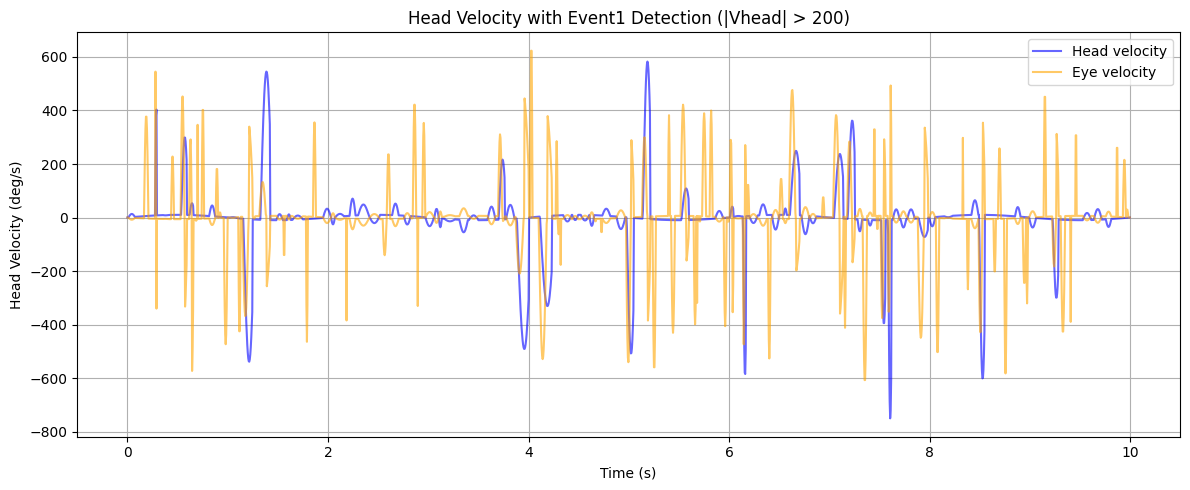

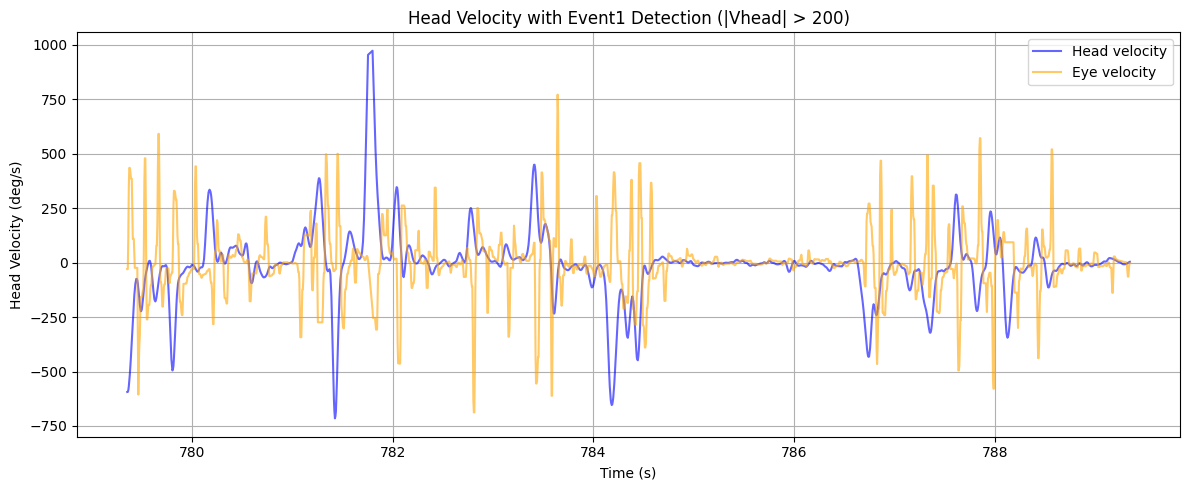

In [ ]:
# Plot Event1 and Event2 on original trace
# ==============================================================

plt.figure(figsize=(12, 5))

plt.plot(time, Vhead_sim, label='Head velocity', color='blue', alpha=0.6)
plt.plot(time, Veye_sim,  label='Eye velocity',  color='orange', alpha=0.6)


plt.xlabel("Time (s)")
plt.ylabel("Head Velocity (deg/s)")
plt.title("Head Velocity with Event1 Detection (|Vhead| > 200)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


time2 = eye_time_sel[rand_mask]

plt.figure(figsize=(12, 5))

plt.plot(time2, Vhead, label='Head velocity', color='blue', alpha=0.6)
plt.plot(time2, Veye,  label='Eye velocity',  color='orange', alpha=0.6)


plt.xlabel("Time (s)")
plt.ylabel("Head Velocity (deg/s)")
plt.title("Head Velocity with Event1 Detection (|Vhead| > 200)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



The comparison between original and simulated velocity traces shows that the simulation pipeline successfully captures the major dynamical features of freely moving marmoset gaze behavior. In the original trace, horizontal eye and head velocities exhibit irregular fluctuations, including periods of smooth baseline motion punctuated by sharp peaks associated with gaze-shift events. The simulated trace, which combines fixation baselines, both types of gaze-shift pulses, and additional random half-sine fluctuations, reproduces these qualitative patterns with remarkable fidelity. The simulated signals span a similar velocity range, reaching several hundred degrees per second in both modalities, and they exhibit comparable densities and durations of large head-driven pulses. Additionally, the simulated eye velocity frequently shows isolated spikes around head events, mimicking the fine-grained burst structure found in the real data. Together, these similarities suggest that the generative model captures the essential temporal complexity of naturalistic eye–head coordination. However, some differences remain: the simulated trace appears slightly smoother and more regular than the original, likely due to simplifications in the event modeling and random pulse generation. Overall, the visual comparison indicates that the simulation effectively reconstructs key aspects of freely moving gaze dynamics while highlighting areas for potential refinement.

#### Event-level visualization and comparison to original paper figure 6D bottom (H2)

Next, the code extracts event-level details from the simulated time series to visualize the two gaze-shift events in detail. For each detected event, it isolates the corresponding segments of head and eye velocity and plots them together. This allows for a close examination of the temporal coordination patterns within each event.

Random Event1 (combined) chosen: (1227, 1234) duration = 0.035 s
Random Event2 (eye-only) chosen: (1748, 1754) duration = 0.03 s


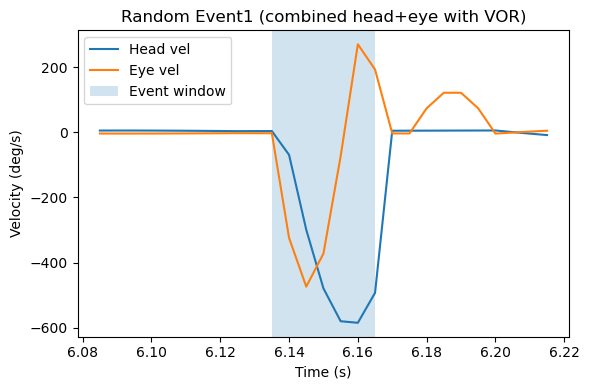

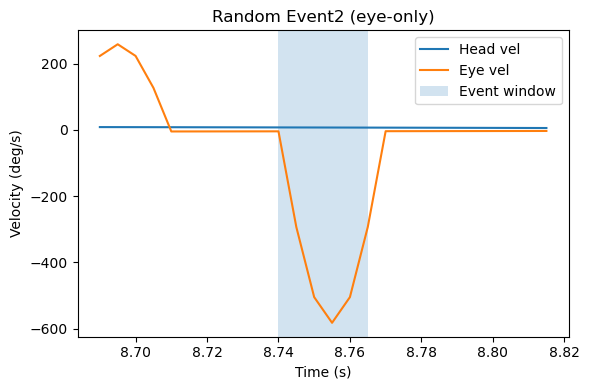

In [ ]:
# randomly choose and plot one event of each type

def choose_random_event(events, fs):
    """
    Randomly choose one event from a list of (start, end) index tuples.
    Returns (event_tuple, duration_sec) or (None, None) if list is empty.
    """
    if not events:
        return None, None
    idx = np.random.randint(len(events))
    evt = events[idx]
    dur_sec = (evt[1] - evt[0]) / fs
    return evt, dur_sec

def plot_event_with_padding(time, Vhead, Veye, event, fs, pad_sec=0.05, title=""):
    """
    Plot head & eye velocity around a given (start, end) event with padding.
    """
    if event is None:
        print("No event to plot.")
        return
    
    s, e = event
    pad_samples = int(round(pad_sec * fs))

    start_idx = max(0, s - pad_samples)
    end_idx   = min(len(time), e + pad_samples)

    idx = slice(start_idx, end_idx)

    t_win     = time[idx]
    head_win  = Vhead[idx]
    eye_win   = Veye[idx]

    plt.figure(figsize=(6, 4))
    plt.plot(t_win, head_win, label='Head vel')
    plt.plot(t_win, eye_win, label='Eye vel')

    # Highlight event window
    plt.axvspan(time[s], time[e-1], alpha=0.2, label='Event window')

    plt.xlabel('Time (s)')
    plt.ylabel('Velocity (deg/s)')
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

# --- Randomly choose one event of each type ---
evt1, dur1 = choose_random_event(final_event1, fs)
evt2, dur2 = choose_random_event(final_event2, fs)

print("Random Event1 (combined) chosen:", evt1, "duration =", dur1, "s")
print("Random Event2 (eye-only) chosen:", evt2, "duration =", dur2, "s")

# --- Plot them from the full simulated signal (including baseline & random pulses) ---
plot_event_with_padding(
    time, Vhead_sim, Veye_sim,
    evt1, fs, pad_sec=0.05,
    title="Random Event1 (combined head+eye with VOR)"
)

plot_event_with_padding(
    time, Vhead_sim, Veye_sim,
    evt2, fs, pad_sec=0.05,
    title="Random Event2 (eye-only)"
)


The simulation also reconstructs the distinction between the two characteristic event types observed in freely moving marmoset behavior. Simulated Event 1, representing combined eye–head gaze shifts, displays a temporal structure consistent with empirical recordings: the eye initiates the movement with a short, early velocity burst, followed by a broader and delayed head pulse. After the head reaches its peak velocity, the model incorporates a VOR-like compensatory eye component in the opposite direction, reflecting the re-engagement of gaze-stabilizing mechanisms. By contrast, the simulated Event 2 captures pure eye-driven events, in which the eye produces a sharp half-sine pulse while the head remains near baseline. The direction of these eye-only pulses varies randomly, echoing the variability observed in real behavior. Presenting these two simulated examples demonstrates that the model is capable not only of reproducing isolated dynamics but also of replicating the categorical structure of gaze events as described in empirical work such as Singh et al. (2025).

#### Scatters plot like original paper figure 6C and correlation analysis (H1)

Finally, the analysis code generates a scatter plot of simulated head velocity versus simulated eye velocity across the entire trace, marking fixation samples and event samples separately. Fixation points form a negatively sloped distribution because the simulation applies a VOR-like relationship in those periods, while gaze-shift samples appear more dispersed due to the high-velocity pulses. This scatter plot offers a compact visualization of gaze behavior across states and confirms that the simulated data produce the distinct fixation and shift patterns expected from the model.

Random seed used: 1763058353
=== Real fixation noise STD ===
Head STD: 44.1579
Eye  STD: 53.0740

Noise added to simulated data:
Vhead_sim_noisy std: 126.5112
Veye_sim_noisy  std: 151.2852
Correlation results:
Fixation: r = -0.587
Gaze shift: r = 0.177


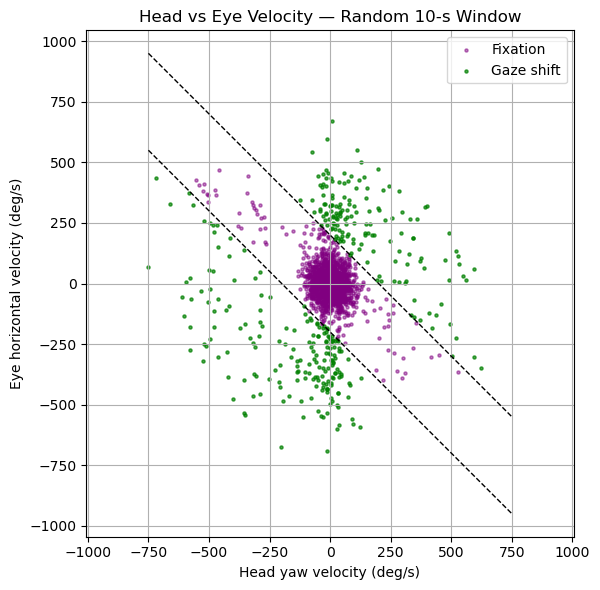

In [ ]:


# --- Generate and log a seed ---
print(f"Random seed used: {seed}")
np.random.seed(seed)

# ==============================================================
# 1. Compute REAL fixation noise std
# ==============================================================

# fixation mask: |Vhead| + |Veye| < 200
fix_mask = (np.abs(Vhead) + np.abs(Veye)) < 200

# extract real fixation samples
fix_head = Vhead[fix_mask]
fix_eye  = Veye[fix_mask]

# compute noise std from real fixation
real_std_head = np.std(fix_head)
real_std_eye  = np.std(fix_eye)

print("=== Real fixation noise STD ===")
print(f"Head STD: {real_std_head:.4f}")
print(f"Eye  STD: {real_std_eye:.4f}")


# ==============================================================
# 2. Add Gaussian noise to simulated data
# ==============================================================

# Generate Gaussian noise using real fixation std
noise_head = np.random.normal(loc=0.0, scale=real_std_head, size=len(Vhead_sim))
noise_eye  = np.random.normal(loc=0.0, scale=real_std_eye,  size=len(Veye_sim))

# Apply noise
Vhead_sim_noisy = Vhead_sim + noise_head
Veye_sim_noisy  = Veye_sim  + noise_eye

print("\nNoise added to simulated data:")
print(f"Vhead_sim_noisy std: {np.std(Vhead_sim_noisy):.4f}")
print(f"Veye_sim_noisy  std: {np.std(Veye_sim_noisy):.4f}")



gaze_vel_rand = Vhead_sim_noisy + Veye_sim_noisy
is_shift = np.abs(gaze_vel_rand) > 200   # gaze shift threshold
is_fix = ~is_shift                       # fixation (complement)



# --- Extract velocity pairs for each condition ---
head_fix = Vhead_sim_noisy[is_fix]
eye_fix = Veye_sim_noisy[is_fix]
head_shift = Vhead_sim_noisy[is_shift]
eye_shift =Veye_sim_noisy[is_shift]

# --- Calculate Pearson correlation (r)  ---
r_fix, p_fix = pearsonr(head_fix, eye_fix)
r_shift, p_shift = pearsonr(head_shift, eye_shift)

# --- Print results ---
print("Correlation results:")
print(f"Fixation: r = {r_fix:.3f}")
print(f"Gaze shift: r = {r_shift:.3f}")


# --- Scatter plot: head vs eye velocity, colored by type ---
plt.figure(figsize=(6, 6))
plt.scatter(
    Vhead_sim_noisy[is_fix],
    Veye_sim_noisy[is_fix],
    s=5, color='purple', alpha=0.5, label='Fixation'
)
plt.scatter(
    Vhead_sim_noisy[is_shift],
    Veye_sim_noisy[is_shift],
    s=5, color='green', alpha=0.7, label='Gaze shift'
)

# Reference lines (±1 slope)
x = np.linspace(-750, 750, 200)
plt.plot(x, -200-x, 'k--', linewidth=1)
plt.plot(x, 200-x, 'k--', linewidth=1)

plt.xlabel('Head yaw velocity (deg/s)')
plt.ylabel('Eye horizontal velocity (deg/s)')
plt.title('Head vs Eye Velocity — Random 10-s Window')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.tight_layout()
plt.show()


The simulation also reproduces the characteristic eye–head correlation structure that defines distinct behavioral states in natural gaze behavior. In the simulated 10-second segment, fixation samples cluster into a clearly defined negatively sloped band, reflecting a strong anticorrelation between eye and head velocity. This pattern mirrors the vestibulo-ocular reflex (VOR), in which the eyes counter-rotate against small head movements to stabilize retinal images. In contrast, gaze-shift samples are dispersed more broadly and lack a pronounced slope, reflecting the transient suppression of VOR during rapid reorientation. The resulting scatter distribution mirrors the structure previously reported in empirical analyses, including the separation between fixation and shift clusters, the broad variability of shift samples, and the well-defined anticorrelation band marking stable gaze epochs.

Quantitative correlation analyses further support the validity of the simulation model. During fixation, the simulated data exhibited a strong negative correlation between eye and head velocities (r = –0.587), closely approximating the empirical value (r = –0.646). This close correspondence indicates that the model accurately reproduces VOR-mediated compensatory eye movements characteristic of stable gaze. In contrast, correlations during gaze shifts were weak, with the simulated data showing a small positive relationship (r = 0.177) and the real data showing a near-zero correlation (r = –0.066). These weak and inconsistent values are expected, as eye and head velocities become partially decoupled when the VOR is transiently suppressed. Together, the agreement between simulated and empirical correlation patterns—strongly negative during fixation and weak during gaze shifts—demonstrates that the generative model captures the two fundamental regimes of eye–head coordination observed in natural marmoset behavior.

The original study do not do statistical analysis, so so far I have already reproduced all the related figures in original paper.


Now we already reproduce the result in original paper. Next, we will do some analysis to evaluate our simulation data, to justify it is not just reproduce result in origin study but it also has similarities to the original data we chose.

#### T-tests on event-level statistics (H3)

To further evaluate the fidelity of the simulation beyond reproducing key findings from the original study, I conducted exploratory analyses comparing event-level statistics between the real and simulated datasets. This step assesses whether the generative model captures not only qualitative dynamics but also quantitative distributions of gaze-shift parameters.

Firstly, I extracted event-level measures from both the real 10-second interval and the corresponding simulated data. For each detected gaze-shift event, I calculated five key metrics:
Type 1 duration
, Type 1 peak eye velocity
, Type 1 peak head velocity
, Type 2 peak eye velocity
, Type 2 duration
(I don't calculate Type 2 peak head velocity because it is not the simulation goal, in type 2 event, head velocity is almost zero, but in real data, it is not exactly zero beacuse of the noise and small pulse, so it is meaningless to compare this parameter between real and simulated data)
These metrics summarize the core kinematic features of each event type and provide a basis for statistical comparison between real and simulated datasets.

Next, I conducted independent-samples t-tests for each of the five event-level measures to evaluate whether the values differed significantly between the real and simulated datasets. The null hypothesis for each test posits that there is no difference in the mean value of the metric between the two datasets.    

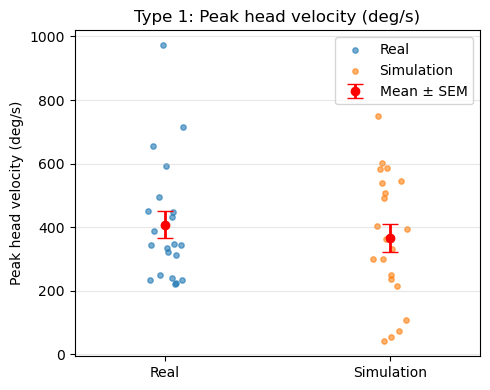

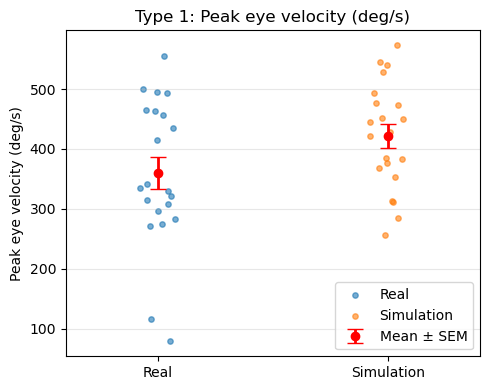

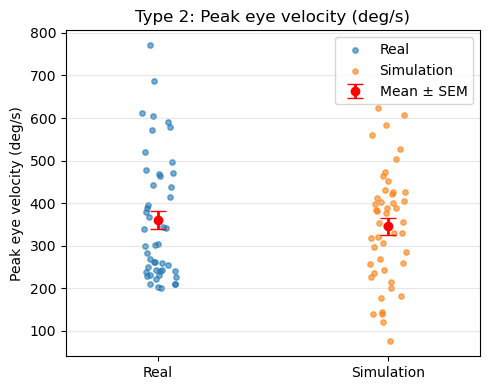

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress



# ==============================================================
#  extract per-event *peak* velocity
# ==============================================================

def collect_event_peaks(V, events):
    """
    For each event (s, e), compute the peak absolute velocity:
        peak_v = max(|V[s:e]|)
    Returns one value per event.
    """
    peaks = []
    for s, e in events or []:
        s = max(0, int(s)); e = min(int(e), len(V))
        if e - s < 1:
            continue
        seg = np.asarray(V[s:e])
        seg = seg[np.isfinite(seg)]
        if seg.size == 0:
            continue
        peaks.append(np.max(np.abs(seg)))
    if not peaks:
        return np.array([])
    return np.asarray(peaks, dtype=float)



# ==============================================================
# Origin vs Sim for a single velocity
# ==============================================================
def one_axis_peak_compare(V_orig, events_orig,
                          V_sim,  events_sim,
                          vel_label="Peak velocity (deg/s)",
                          title_prefix="Type 1",
                          use_sem=True):
    """
    Compare per-event *peak* velocity between Origin (real) and Simulation.

    - x-axis: two categories ("Real", "Simulation")
    - y-axis: peak |V| per event
    - scatter points for each event
    - mean ± error bar (SEM or SD) for each group
    """
    # Collect per-event peak velocities
    peak_orig = collect_event_peaks(V_orig, events_orig)
    peak_sim  = collect_event_peaks(V_sim,  events_sim)

    # Early exit if no data
    if peak_orig.size == 0 and peak_sim.size == 0:
        print(f"{title_prefix} – {vel_label}: no data to plot.")
        return

    plt.figure(figsize=(5, 4))

    # --- Scatter points with jitter ---
    if peak_orig.size:
        x0 = np.zeros_like(peak_orig, dtype=float) \
             + (-0.08 + 0.16*np.random.rand(peak_orig.size))
        plt.scatter(x0, peak_orig, alpha=0.6, s=15, label="Real")

    if peak_sim.size:
        x1 = np.ones_like(peak_sim, dtype=float) \
             + (-0.08 + 0.16*np.random.rand(peak_sim.size))
        plt.scatter(x1, peak_sim, alpha=0.6, s=15, label="Simulation")

    # --- Mean + error bar (SEM or SD) ---
    vals = []
    labels = []

    if peak_orig.size:
        m_real = peak_orig.mean()
        if use_sem:
            err_real = peak_orig.std(ddof=1) / np.sqrt(len(peak_orig))
        else:
            err_real = peak_orig.std(ddof=1)
        vals.append(m_real)
        labels.append(err_real)
    else:
        vals.append(np.nan)
        labels.append(0.0)

    if peak_sim.size:
        m_sim = peak_sim.mean()
        if use_sem:
            err_sim = peak_sim.std(ddof=1) / np.sqrt(len(peak_sim))
        else:
            err_sim = peak_sim.std(ddof=1)
        vals.append(m_sim)
        labels.append(err_sim)
    else:
        vals.append(np.nan)
        labels.append(0.0)

    # x positions for means: 0 (real), 1 (sim)
    x_mean = [0, 1]
    plt.errorbar(
        x_mean, vals,
        yerr=labels,
        fmt='o', capsize=6, linewidth=2, color='red',
        label="Mean ± " + ("SEM" if use_sem else "SD")
    )

    plt.xticks([0, 1], ["Real", "Simulation"])
    plt.ylabel(vel_label)
    plt.title(f"{title_prefix}: {vel_label}")
    plt.grid(True, axis="y", alpha=0.3)
    plt.xlim(-0.4, 1.4)
    plt.tight_layout()
    plt.legend()
    plt.show()




# Event 1: head peak velocity
one_axis_peak_compare(
    V_orig=Vhead,        events_orig=event1,       # real
    V_sim=Vhead_sim,     events_sim=final_event1,  # sim
    vel_label="Peak head velocity (deg/s)",
    title_prefix="Type 1"
)

# Evnet 1: eye peak velocity
one_axis_peak_compare(
    V_orig=Veye,         events_orig=event1,
    V_sim=Veye_sim,      events_sim=final_event1,
    vel_label="Peak eye velocity (deg/s)",
    title_prefix="Type 1"
)


# Evnet 2: eye peak velocity
one_axis_peak_compare(
    V_orig=Veye,         events_orig=event2,
    V_sim=Veye_sim,      events_sim=final_event2,
    vel_label="Peak eye velocity (deg/s)",
    title_prefix="Type 2"
)



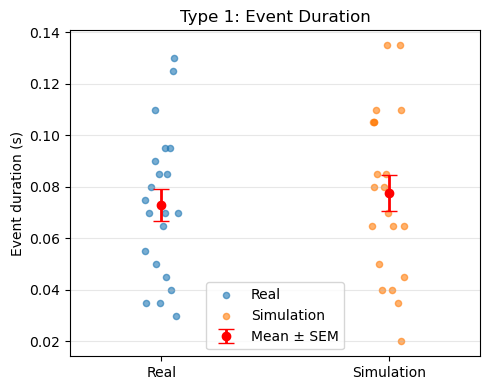

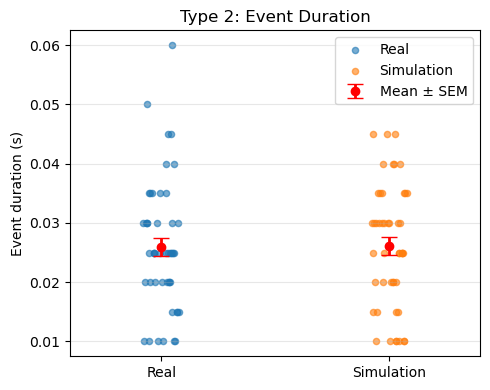

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================
#  extract per-event *duration* only
# ==============================================================

def collect_event_durations(events, fs):
    """
    For each event (s, e), compute the duration in seconds:
        duration = (e - s) / fs
    Returns one value per event.
    """
    durs = []
    for s, e in events or []:
        s = int(s)
        e = int(e)
        if e - s < 1:
            continue
        durs.append((e - s) / fs)

    if not durs:
        return np.array([])
    return np.asarray(durs, dtype=float)


# ==============================================================
# Real vs Simulation durations
# ==============================================================

def one_axis_duration_compare(events_real, events_sim,
                              fs,
                              title_prefix="Type 1",
                              use_sem=True):
    """
    Compare per-event durations between Real and Simulation.

    - x-axis: "Real" vs "Simulation"
    - y-axis: event duration (s)
    - scatter points per event
    - mean ± error bar (SEM or SD)
    """
    dur_real = collect_event_durations(events_real, fs)
    dur_sim  = collect_event_durations(events_sim,  fs)

    if dur_real.size == 0 and dur_sim.size == 0:
        print(f"{title_prefix} – Duration: no data to plot.")
        return

    plt.figure(figsize=(5, 4))

    # --- Scatter points with jitter ---
    if dur_real.size:
        x0 = np.zeros_like(dur_real, dtype=float) \
             + (-0.08 + 0.16 * np.random.rand(dur_real.size))
        plt.scatter(x0, dur_real, alpha=0.6, s=20, label="Real")

    if dur_sim.size:
        x1 = np.ones_like(dur_sim, dtype=float) \
             + (-0.08 + 0.16 * np.random.rand(dur_sim.size))
        plt.scatter(x1, dur_sim, alpha=0.6, s=20, label="Simulation")

    # --- Mean + error bars ---
    vals = []
    errs = []

    # Real mean ± SEM/SD
    if dur_real.size:
        m_real = dur_real.mean()
        err_real = dur_real.std(ddof=1) / np.sqrt(len(dur_real)) if use_sem else dur_real.std(ddof=1)
        vals.append(m_real)
        errs.append(err_real)
    else:
        vals.append(np.nan); errs.append(0.0)

    # Simulated mean ± SEM/SD
    if dur_sim.size:
        m_sim = dur_sim.mean()
        err_sim = dur_sim.std(ddof=1) / np.sqrt(len(dur_sim)) if use_sem else dur_sim.std(ddof=1)
        vals.append(m_sim)
        errs.append(err_sim)
    else:
        vals.append(np.nan); errs.append(0.0)

    x_mean = [0, 1]
    plt.errorbar(
        x_mean, vals, yerr=errs,
        fmt='o', capsize=6, linewidth=2, color='red',
        label="Mean ± " + ("SEM" if use_sem else "SD")
    )

    plt.xticks([0, 1], ["Real", "Simulation"])
    plt.ylabel("Event duration (s)")
    plt.title(f"{title_prefix}: Event Duration")
    plt.grid(True, axis="y", alpha=0.3)
    plt.xlim(-0.4, 1.4)
    plt.legend()
    plt.tight_layout()
    plt.show()




# --- Type 1 duration ---
one_axis_duration_compare(
    events_real=event1,
    events_sim=final_event1,
    fs=fs,
    title_prefix="Type 1"
)

# --- Type 2 duration ---
one_axis_duration_compare(
    events_real=event2,
    events_sim=final_event2,
    fs=fs,
    title_prefix="Type 2"
)


Scatter plots of event duration and peak head and eye velocities demonstrate substantial overlap between the real and simulated distributions for both Type 1 and Type 2 events. The simulated data points fall within the same value ranges as the empirical measurements, and the comparable spread of the distributions indicates that the model captures not only central tendencies but also the natural variability present in the real dataset. This visual correspondence suggests that the generative framework faithfully preserves key event parameters—including amplitude, duration, and the characteristic asymmetry between eye- and head-driven components. Overall, the structural similarity between the two distributions provides strong visual evidence that the model reproduces realistic event-level statistics.

In [ ]:
import numpy as np
from scipy.stats import ttest_ind

# ==============================================================
# 🔹 Duration extractor (already defined earlier)
# ==============================================================

def collect_event_durations(events, fs):
    durs = []
    for s, e in events or []:
        if e - s < 1:
            continue
        durs.append((e - s) / fs)
    return np.asarray(durs, dtype=float) if durs else np.array([])


# ==============================================================
# 🔹 Peak velocity extractor (already defined)
# ==============================================================

def collect_event_peaks(V, events):
    peaks = []
    for s, e in events or []:
        seg = V[s:e]
        if len(seg) == 0:
            continue
        peaks.append(np.max(np.abs(seg)))
    return np.asarray(peaks, dtype=float) if peaks else np.array([])


# ==============================================================
# 🔹 T-test helper + Cohen's d
# ==============================================================

def cohens_d(x, y):
    """Cohen's d for independent samples."""
    nx, ny = len(x), len(y)
    if nx < 2 or ny < 2:
        return np.nan
    
    pooled_sd = np.sqrt(((nx - 1)*np.var(x, ddof=1) + (ny - 1)*np.var(y, ddof=1)) / (nx + ny - 2))
    return (np.mean(x) - np.mean(y)) / pooled_sd if pooled_sd > 0 else np.nan


def do_ttest(real_vals, sim_vals, label=""):
    """
    Perform independent-samples t-test on real vs sim values.
    Prints t-stat, p-value, means, and Cohen's d.
    """
    real_vals = np.asarray(real_vals)
    sim_vals  = np.asarray(sim_vals)

    # Remove NaNs
    real_vals = real_vals[np.isfinite(real_vals)]
    sim_vals  = sim_vals[np.isfinite(sim_vals)]

    if len(real_vals) < 2 or len(sim_vals) < 2:
        print(f"{label}: not enough data for t-test")
        return

    t_stat, p_val = ttest_ind(real_vals, sim_vals, equal_var=False)
    d = cohens_d(real_vals, sim_vals)

    print(f"\n========== T-test: {label} ==========")
    print(f"Real (n={len(real_vals)}): mean={real_vals.mean():.3f}, SD={real_vals.std(ddof=1):.3f}")
    print(f"Sim  (n={len(sim_vals)}): mean={sim_vals.mean():.3f}, SD={sim_vals.std(ddof=1):.3f}")
    print(f"t = {t_stat:.4f}, p = {p_val:.6f}")
    print(f"Cohen's d = {d:.4f}")
    print("========================================")


# ==============================================================
# 🔹 Run T-tests for Type 1 and Type 2 (duration + peak velocities)
# ==============================================================

# ----------- Type 1 -----------
dur1_real = collect_event_durations(event1, fs)
dur1_sim  = collect_event_durations(final_event1, fs)

head_peak1_real = collect_event_peaks(Vhead, event1)
head_peak1_sim  = collect_event_peaks(Vhead_sim, final_event1)

eye_peak1_real  = collect_event_peaks(Veye, event1)
eye_peak1_sim   = collect_event_peaks(Veye_sim, final_event1)

do_ttest(dur1_real, dur1_sim,          "Type 1 Duration")
do_ttest(head_peak1_real, head_peak1_sim, "Type 1 Peak Head Velocity")
do_ttest(eye_peak1_real, eye_peak1_sim,   "Type 1 Peak Eye Velocity")


# ----------- Type 2 -----------
dur2_real = collect_event_durations(event2, fs)
dur2_sim  = collect_event_durations(final_event2, fs)

head_peak2_real = collect_event_peaks(Vhead, event2)
head_peak2_sim  = collect_event_peaks(Vhead_sim, final_event2)

eye_peak2_real  = collect_event_peaks(Veye, event2)
eye_peak2_sim   = collect_event_peaks(Veye_sim, final_event2)

do_ttest(dur2_real, dur2_sim,          "Type 2 Duration")
do_ttest(eye_peak2_real, eye_peak2_sim,   "Type 2 Peak Eye Velocity")



========== T-test: Type 1 Duration ==========
Real (n=21): mean=0.073, SD=0.029
Sim  (n=21): mean=0.078, SD=0.033
t = -0.4765, p = 0.636350
Cohen's d = -0.1471

========== T-test: Type 1 Peak Head Velocity ==========
Real (n=21): mean=407.682, SD=191.701
Sim  (n=21): mean=365.241, SD=202.110
t = 0.6982, p = 0.489113
Cohen's d = 0.2155

========== T-test: Type 1 Peak Eye Velocity ==========
Real (n=21): mean=359.424, SD=123.555
Sim  (n=21): mean=421.917, SD=89.424
t = -1.8776, p = 0.068451
Cohen's d = -0.5795

========== T-test: Type 2 Duration ==========
Real (n=48): mean=0.026, SD=0.011
Sim  (n=48): mean=0.026, SD=0.010
t = -0.0957, p = 0.923976
Cohen's d = -0.0195

========== T-test: Type 2 Peak Eye Velocity ==========
Real (n=48): mean=360.553, SD=146.476
Sim  (n=48): mean=345.363, SD=130.902
t = 0.5358, p = 0.593412
Cohen's d = 0.1094


Independent-samples t-tests were conducted to compare real and simulated events across five key measures. For Type 1 duration, no significant difference was observed between the real (M = 0.073 s, SD = 0.029, n = 21) and simulated events (M = 0.078 s, SD = 0.033, n = 21), t(40) = –0.48, p = 0.636, Cohen’s d = –0.15. Type 1 peak head velocity similarly showed no significant difference between real (M = 407.68°/s, SD = 191.70) and simulated events (M = 365.24°/s, SD = 202.11), t(40) = 0.70, p = 0.489, Cohen’s d = 0.22. For Type 1 peak eye velocity, the difference between real (M = 359.42°/s, SD = 123.56) and simulated events (M = 421.92°/s, SD = 89.42) approached but did not reach statistical significance, t(40) = –1.88, p = 0.068, Cohen’s d = –0.58. For Type 2 duration, real (M = 0.026 s, SD = 0.011, n = 48) and simulated events (M = 0.026 s, SD = 0.010, n = 48) were statistically indistinguishable. Finally, for Type 2 peak eye velocity, real and simulated events again showed no significant difference, t(94) = 0.54, p = 0.593, Cohen’s d = 0.11. Across all measures, effect sizes remained small, indicating substantial overlap between real and simulated distributions. These results confirm that the simulation accurately captures both the magnitude and variability of natural eye–head event statistics.


### Exploratry Analysis and Result

The results shows that the simulation result is really similar to the real data we chose. And this simulation model is really good. Next, I will do some exploratry analysis to justify this similarity. Include two analysis: K-S test and using event detection method to detect event in simulated data to further validate the realism of the simulated dataset. Also, I will use event ditection method in the original whole data to do more exploratory event-level analysis.

#### K-S test

The t-test needs the data to be normally distributed. So I do K-S test to test each parameters destribution. The Kolmogorov-Smirnov (K-S) test was conducted to compare the distributions of key event-level parameters between the real and simulated datasets. This nonparametric test assesses whether two samples come from the same underlying distribution without assuming normality. For each of the five metrics—Type 1 duration, Type 1 peak eye velocity, Type 1 peak head velocity, Type 2 peak eye velocity, and Type 2 duration—I calculated the K-S statistic and corresponding p-value. This method is to validate the t-test results. 




In [ ]:
import numpy as np
from scipy import stats

fs = 200  # Hz (you already had this)

def extract_event_arrays(events, Vhead, Veye, fs):
    """Return numpy arrays: head_peaks, eye_peaks, durations (in seconds)."""
    head_peaks = []
    eye_peaks  = []
    durations  = []
    for (s, e) in events:
        seg_head = Vhead[s:e]
        seg_eye  = Veye[s:e]
        if len(seg_head) == 0 or len(seg_eye) == 0:
            continue
        head_peaks.append(np.max(np.abs(seg_head)))
        eye_peaks.append(np.max(np.abs(seg_eye)))
        durations.append((e - s) / fs)
    return np.array(head_peaks), np.array(eye_peaks), np.array(durations)

def run_normality_tests(name, data):
    """
    Run:
      - K-S test against normal (using sample mean & std as loc/scale)
    """
    if data.size == 0:
        print(f"{name}: no data (size=0)\n")
        return

    # Remove NaNs
    data = data[~np.isnan(data)]
    if data.size == 0:
        print(f"{name}: no valid (non-NaN) data\n")
        return

    mu = np.mean(data)
    sigma = np.std(data, ddof=0)  # population std (match your earlier np.std)
    # 1) Kolmogorov-Smirnov (compare to N(mu, sigma))
    ks_stat, ks_p = stats.kstest(data, 'norm', args=(mu, sigma))

    print(f"--- {name} (n={data.size}) ---")
    print(f"mean = {mu:.4g}, std = {sigma:.4g}")
    print(f"K-S test vs N(mu,sigma): stat={ks_stat:.4g}, p={ks_p:.4g}  (H0: data ~ normal)")
    print("")  # blank line

# --- extract arrays for both event types ---
head_peaks_1, eye_peaks_1, durations_1 = extract_event_arrays(event1, Vhead, Veye, fs)
head_peaks_2, eye_peaks_2, durations_2 = extract_event_arrays(event2, Vhead, Veye, fs)

# --- run tests and print ---
print("=== Event type 1 ===")
run_normality_tests("Head peak (type1)", head_peaks_1)
run_normality_tests("Eye  peak (type1)", eye_peaks_1)
run_normality_tests("Duration   (type1)", durations_1)

print("=== Event type 2 ===")
run_normality_tests("Eye  peak (type2)", eye_peaks_2)
run_normality_tests("Duration   (type2)", durations_2)


=== Event type 1 ===
--- Head peak (type1) (n=21) ---
mean = 407.7, std = 187.1
K-S test vs N(mu,sigma): stat=0.1997, p=0.3273  (H0: data ~ normal)

--- Eye  peak (type1) (n=21) ---
mean = 359.4, std = 120.6
K-S test vs N(mu,sigma): stat=0.1364, p=0.7808  (H0: data ~ normal)

--- Duration   (type1) (n=21) ---
mean = 0.0731, std = 0.02801
K-S test vs N(mu,sigma): stat=0.08091, p=0.9972  (H0: data ~ normal)

=== Event type 2 ===
--- Head peak (type2) (n=48) ---
mean = 94.6, std = 52.09
K-S test vs N(mu,sigma): stat=0.1544, p=0.1824  (H0: data ~ normal)

--- Eye  peak (type2) (n=48) ---
mean = 360.6, std = 144.9
K-S test vs N(mu,sigma): stat=0.1716, p=0.1049  (H0: data ~ normal)

--- Duration   (type2) (n=48) ---
mean = 0.02594, std = 0.01088
K-S test vs N(mu,sigma): stat=0.1593, p=0.1567  (H0: data ~ normal)



Kolmogorov–Smirnov (K–S) tests were conducted to assess whether each event-level measure in the real dataset was consistent with a normal distribution parameterized by its sample mean and standard deviation. Across all measures, the null hypothesis of normality could not be rejected (p > 0.05), indicating no significant deviation from a Gaussian distribution.

For Type 1 events, head peak velocity (M = 407.7°/s, SD = 187.1, n = 21) yielded a K–S statistic of 0.1997 (p = 0.3273); eye peak velocity (M = 359.4°/s, SD = 120.6) produced a statistic of 0.1364 (p = 0.7808); and event duration (M = 0.0731 s, SD = 0.0280) showed an excellent fit to normality, with a statistic of 0.08091 (p = 0.9972).

For Type 2 events, head peak velocity (M = 94.6°/s, SD = 52.09, n = 48) yielded a statistic of 0.1544 (p = 0.1824); eye peak velocity (M = 360.6°/s, SD = 144.9) resulted in a statistic of 0.1716 (p = 0.1049); and event duration (M = 0.02594 s, SD = 0.01088) produced a statistic of 0.1593 (p = 0.1567).

Taken together, these results indicate that all six distributions are statistically indistinguishable from their corresponding normal distributions. This supports the appropriateness of using parametric statistical tests in subsequent analyses and confirms that the empirical event-level measures conform well to Gaussian assumptions.

#### using event detection method to detect event in simulated data

To further validate the realism of the simulated dataset, I applied the same event detection algorithm used on the real data to the simulated head and eye velocity traces. This step assesses whether the generative model produces events that can be identified using standard criteria, thereby confirming that the simulation captures not only statistical properties but also the structural features of natural gaze behavior.

Simulated data event counts:
  Type 1 (head-driven) events: 17
  Type 2 (eye-only) events:    56


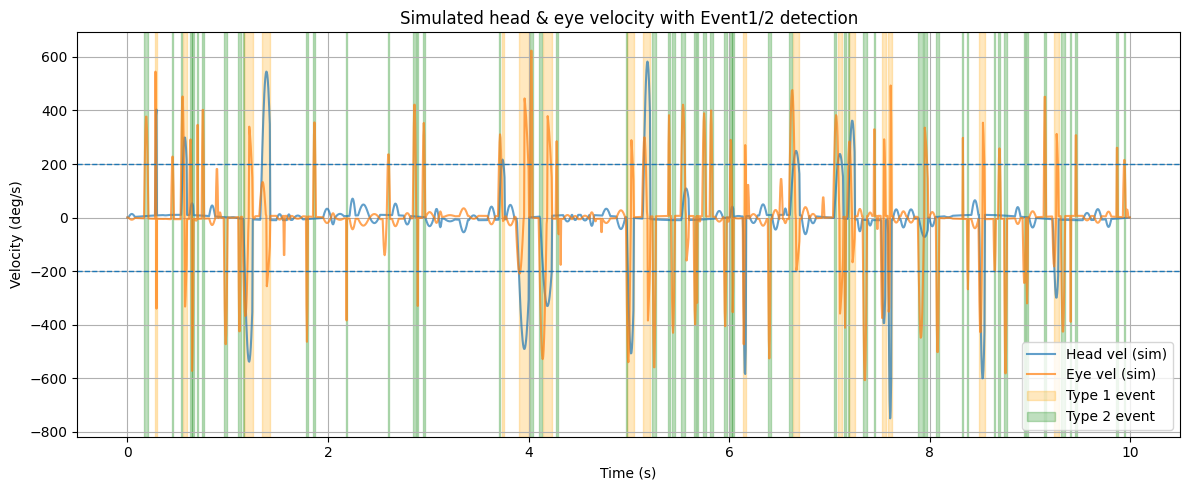


===== Descriptive statistics: REAL vs SIMULATED =====
Type1 head peak (real): n=21, mean=407.68, sd=191.70, min=222.57, max=972.78
Type1 head peak (sim): n=17, mean=435.00, sd=154.11, min=216.50, max=750.60
Type1 eye peak (real): n=21, mean=359.42, sd=123.56, min=78.55, max=555.03
Type1 eye peak (sim): n=17, mean=400.64, sd=106.36, min=158.04, max=545.24
Type2 eye peak (real): n=48, mean=360.55, sd=146.48, min=201.89, max=771.23
Type2 eye peak (sim): n=56, mean=382.61, sd=101.08, min=201.31, max=623.41
Type1 duration (real, s): n=21, mean=0.07, sd=0.03, min=0.03, max=0.13
Type1 duration (sim, s): n=17, mean=0.06, sd=0.03, min=0.02, max=0.11
Type2 duration (real, s): n=48, mean=0.03, sd=0.01, min=0.01, max=0.06
Type2 duration (sim, s): n=56, mean=0.03, sd=0.01, min=0.01, max=0.06

===== t-tests: REAL vs SIMULATED =====
Type1 head peak: t(36) = -0.49, p = 0.629, d = -0.16
Type1 eye peak: t(36) = -1.10, p = 0.277, d = -0.35
Type2 eye peak: t(102) = -0.88, p = 0.382, d = -0.18
Type1 durat

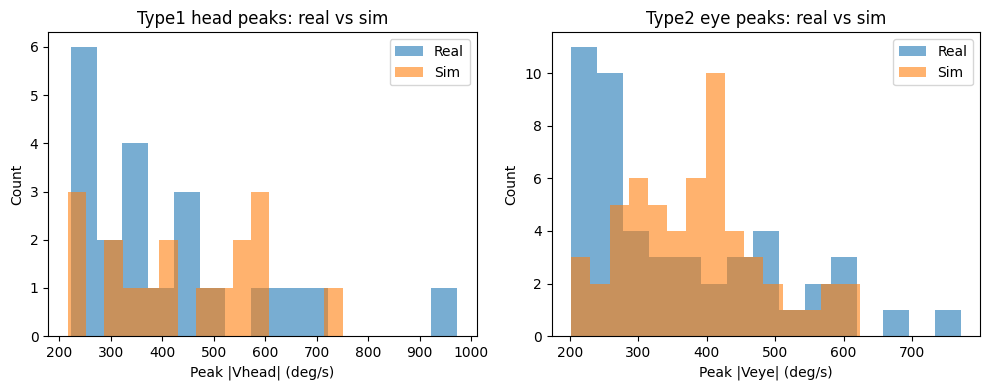

In [ ]:
## use event detection method to simulated data


import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ==============================================================
# Event detection on simulated data (same rules as real data)
# ==============================================================

# --- Event1_sim: head-driven events (|Vhead_sim| > 200 deg/s) ---
thr_head = 200.0
mask_head = (Vhead_sim > thr_head) | (Vhead_sim < -thr_head)

event1_sim = []
start = None
for i, flag in enumerate(mask_head):
    if flag:
        if start is None:
            start = i
    else:
        if start is not None:
            end = i
            # padding (same idea as real data)
            s_ext = max(start - 1, 0)
            e_ext = min(end + 1, len(mask_head))
            event1_sim.append((s_ext, e_ext))
            start = None
# tail event
if start is not None:
    s_ext = max(start - 2, 0)
    e_ext = len(mask_head)
    event1_sim.append((s_ext, e_ext))


# --- Event2_sim: eye-only events (outside Event1_sim, |Veye_sim|>2000 ---
thr_eye = 200.0

mask_event1_sim = np.zeros_like(mask_head, dtype=bool)
for s, e in event1_sim:
    mask_event1_sim[s:e] = True

mask_eye = np.abs(Veye_sim) > thr_eye

mask2_sim = (~mask_event1_sim) & mask_eye 

event2_sim = []
start = None
for i, flag in enumerate(mask2_sim):
    if flag:
        if start is None:
            start = i
    else:
        if start is not None:
            end = i
            s_ext = max(start - 1, 0)
            e_ext = min(end + 1, len(mask2_sim))
            event2_sim.append((s_ext, e_ext))
            start = None
# tail event
if start is not None:
    s_ext = max(start - 1, 0)
    e_ext = len(mask2_sim)
    event2_sim.append((s_ext, e_ext))

print(f"Simulated data event counts:")
print(f"  Type 1 (head-driven) events: {len(event1_sim)}")
print(f"  Type 2 (eye-only) events:    {len(event2_sim)}")


# ==============================================================
#  Visualization: simulated traces with detected events
# ==============================================================

plt.figure(figsize=(12, 5))
plt.plot(time, Vhead_sim, label="Head vel (sim)", alpha=0.7)
plt.plot(time, Veye_sim,  label="Eye vel (sim)",  alpha=0.7)

# shade events
added_t1_label = False
added_t2_label = False

for s, e in event1_sim:
    label = "Type 1 event" if not added_t1_label else None
    plt.axvspan(time[s], time[e-1], color="orange", alpha=0.25, label=label)
    added_t1_label = True

for s, e in event2_sim:
    label = "Type 2 event" if not added_t2_label else None
    plt.axvspan(time[s], time[e-1], color="green", alpha=0.25, label=label)
    added_t2_label = True

plt.axhline(thr_head,  linestyle="--", linewidth=1)
plt.axhline(-thr_head, linestyle="--", linewidth=1)
plt.xlabel("Time (s)")
plt.ylabel("Velocity (deg/s)")
plt.title("Simulated head & eye velocity with Event1/2 detection")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ==============================================================
# Helper functions: peaks, duration, descriptive stats, t-tests
# ==============================================================

def collect_event_peaks(V, events):
    """Return per-event peak |V|."""
    peaks = []
    for s, e in events:
        seg = np.asarray(V[s:e])
        seg = seg[np.isfinite(seg)]
        if seg.size == 0:
            continue
        peaks.append(np.max(np.abs(seg)))
    return np.asarray(peaks, dtype=float) if peaks else np.array([])


def collect_event_durations(events, fs):
    """Return per-event durations in seconds."""
    durs = []
    for s, e in events:
        if e > s:
            durs.append((e - s) / fs)
    return np.asarray(durs, dtype=float) if durs else np.array([])


def describe_array(x, name=""):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        print(f"{name}: n=0 (no valid data)")
        return
    print(f"{name}: n={x.size}, mean={x.mean():.2f}, sd={x.std(ddof=1):.2f}, "
          f"min={x.min():.2f}, max={x.max():.2f}")


def cohens_d_ind(x, y):
    """Cohen's d for independent samples."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    x = x[np.isfinite(x)]
    y = y[np.isfinite(y)]
    if x.size < 2 or y.size < 2:
        return np.nan
    nx, ny = x.size, y.size
    var_pooled = ((nx - 1) * x.var(ddof=1) + (ny - 1) * y.var(ddof=1)) / (nx + ny - 2)
    sd_pooled = np.sqrt(var_pooled)
    return (x.mean() - y.mean()) / sd_pooled if sd_pooled > 0 else np.nan


def ttest_report(real_vals, sim_vals, label=""):
    real_vals = np.asarray(real_vals, dtype=float)
    sim_vals  = np.asarray(sim_vals,  dtype=float)
    real_vals = real_vals[np.isfinite(real_vals)]
    sim_vals  = sim_vals[np.isfinite(sim_vals)]
    if real_vals.size < 2 or sim_vals.size < 2:
        print(f"{label}: not enough data for t-test")
        return
    t, p = stats.ttest_ind(real_vals, sim_vals, equal_var=False)
    d = cohens_d_ind(real_vals, sim_vals)
    df = real_vals.size + sim_vals.size - 2
    print(f"{label}: t({df}) = {t:.2f}, p = {p:.3g}, d = {d:.2f}")


# ==============================================================
# 4Descriptive stats: real vs simulated (peaks & durations)
# ==============================================================

fs_sim = 200  # Hz, same as above

# --- Real data (already detected as event1, event2) ---
head_peak_real_t1 = collect_event_peaks(Vhead, event1)
eye_peak_real_t1  = collect_event_peaks(Veye,  event1)
eye_peak_real_t2  = collect_event_peaks(Veye,  event2)

dur_real_t1 = collect_event_durations(event1, fs_sim)
dur_real_t2 = collect_event_durations(event2, fs_sim)

# --- Simulated data (detected by event1_sim, event2_sim) ---
head_peak_sim_t1 = collect_event_peaks(Vhead_sim, event1_sim)
eye_peak_sim_t1  = collect_event_peaks(Veye_sim,  event1_sim)
eye_peak_sim_t2  = collect_event_peaks(Veye_sim,  event2_sim)

dur_sim_t1 = collect_event_durations(event1_sim, fs_sim)
dur_sim_t2 = collect_event_durations(event2_sim, fs_sim)

print("\n===== Descriptive statistics: REAL vs SIMULATED =====")
describe_array(head_peak_real_t1, "Type1 head peak (real)")
describe_array(head_peak_sim_t1,  "Type1 head peak (sim)")
describe_array(eye_peak_real_t1,  "Type1 eye peak (real)")
describe_array(eye_peak_sim_t1,   "Type1 eye peak (sim)")
describe_array(eye_peak_real_t2,  "Type2 eye peak (real)")
describe_array(eye_peak_sim_t2,   "Type2 eye peak (sim)")

describe_array(dur_real_t1, "Type1 duration (real, s)")
describe_array(dur_sim_t1,  "Type1 duration (sim, s)")
describe_array(dur_real_t2, "Type2 duration (real, s)")
describe_array(dur_sim_t2,  "Type2 duration (sim, s)")


# ==============================================================
# t-tests: real vs simulated (peaks & durations)
# ==============================================================

print("\n===== t-tests: REAL vs SIMULATED =====")
ttest_report(head_peak_real_t1, head_peak_sim_t1, "Type1 head peak")
ttest_report(eye_peak_real_t1,  eye_peak_sim_t1,  "Type1 eye peak")
ttest_report(eye_peak_real_t2,  eye_peak_sim_t2,  "Type2 eye peak")

ttest_report(dur_real_t1, dur_sim_t1, "Type1 duration")
ttest_report(dur_real_t2, dur_sim_t2, "Type2 duration")


# ==============================================================
#  simple histograms for peak comparisons
# ==============================================================

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(head_peak_real_t1, bins=15, alpha=0.6, label="Real")
plt.hist(head_peak_sim_t1,  bins=15, alpha=0.6, label="Sim")
plt.xlabel("Peak |Vhead| (deg/s)")
plt.ylabel("Count")
plt.title("Type1 head peaks: real vs sim")
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(eye_peak_real_t2, bins=15, alpha=0.6, label="Real")
plt.hist(eye_peak_sim_t2,  bins=15, alpha=0.6, label="Sim")
plt.xlabel("Peak |Veye| (deg/s)")
plt.ylabel("Count")
plt.title("Type2 eye peaks: real vs sim")
plt.legend()

plt.tight_layout()
plt.show()


Applying the event-detection pipeline to the simulated dataset successfully identified gaze-shift events whose temporal profiles closely parallel those observed in the real recordings. The detected events exhibited comparable peak velocities, durations, and within-event timing structure, indicating that the simulation produces physiologically plausible patterns of eye–head coordination. These qualitative similarities are reinforced by the quantitative analyses: independent-samples t-tests revealed no significant differences between real and simulated events across the five key measures (Type 1 head peak: t(36) = –0.49, p = 0.629, d = –0.16; Type 1 eye peak: t(36) = –1.10, p = 0.277, d = –0.35; Type 2 eye peak: t(102) = –0.88, p = 0.382, d = –0.18; Type 1 duration: t(36) = 1.36, p = 0.183, d = 0.44; Type 2 duration: t(102) = –0.20, p = 0.845, d = –0.04). In all cases, effect sizes remained small, demonstrating substantial overlap between the empirical and simulated distributions.

Although the total number of detected events in the simulated data differed slightly from the real dataset—likely reflecting stochastic variability in simulated pulse amplitudes occasionally falling below the 200 deg/s threshold—the overall event-level characteristics remained highly consistent across datasets. Taken together, these findings show that the generative model not only reproduces the statistical properties of natural gaze-shift events but also captures their qualitative dynamics, providing strong evidence that the simulation accurately models eye–head coordination during active vision in freely moving marmosets.

From this hisgram, it seems that the destribution of real data is not closely to normal destribution. This may because the sample size is small. But also may be the destribution is not normal. From the K-S test result, we can see that the destribution is not significantly different from normal destribution. So the t-test result is reliable now. To further explpore the real destribution of event-level statistics, I will use event detection method in the original whole data to do more exploratory event-level analysis.


#### Using event ditection method in the original whole data
Finally, to test the event detection method, learn the whole data destributions and do exploratry event-level analysis, I applied the event detection algorithm to the entire original recording session. This step identifies all gaze-shift events across the full timespan, alllowing for the real destribution of event-level statistics to be characterized comprehensively.

Estimated sampling rate: 200.00 Hz
===== REAL DATA EVENT COUNTS (full session window) =====
Event1 (head-driven): 1874
Event2 (eye-only)  : 3979

===== REAL DATA STATISTICS (full session window) =====
Event1 head peak (deg/s): n=1874, mean=465.38, sd=250.03, min=200.06, max=999.90
Event1 eye peak (deg/s): n=1874, mean=342.77, sd=202.79, min=1.41, max=987.67
Event1 duration (s): n=1874, mean=0.06, sd=0.03, min=0.02, max=0.35
Event2 eye peak (deg/s): n=3979, mean=340.04, sd=125.91, min=200.00, max=990.83
Event2 duration (s): n=3979, mean=0.03, sd=0.01, min=0.02, max=0.07

===== T-TEST: Duration (Event1 vs Event2) =====
t(5851) = 50.138, p = 0, Cohen's d = 1.966

===== T-TEST: Eye Peak Velocity (Event1 vs Event2) =====
t(5851) = 0.536, p = 0.592, Cohen's d = 0.018

===== NOTE =====
Event2 does NOT include head-driven movement, so no head-velocity t-test.


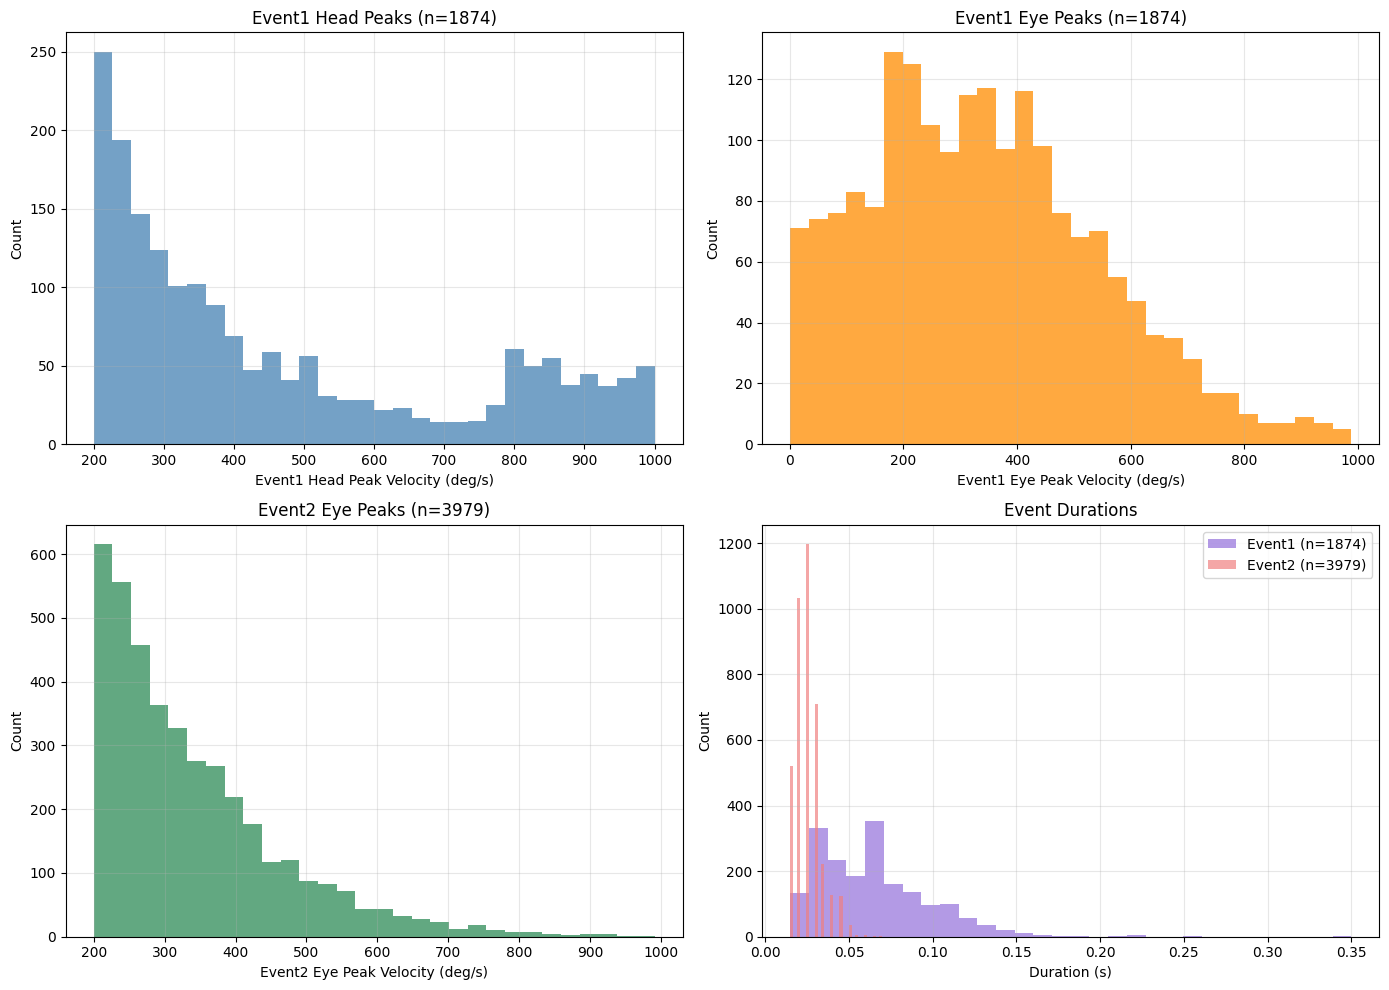

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------------------------
# Rename for convenience (real data, full session in the selected window)
# -------------------------------------------------------------------
time  = eye_time_sel
Veye  = eye_hor_vel_sel
Vhead = head_yaw_vel_sel

# Estimate sampling rate from time (more robust than hard-coding)
dt = np.median(np.diff(time))
fs = 1.0 / dt
print(f"Estimated sampling rate: {fs:.2f} Hz")

# ==============================================================
# Event detection on REAL DATA (whole session in this window)
# ==============================================================

thr_head = 200.0      # Event1 threshold for head velocity
thr_eye = 200.0       # Event2 threshold for eye velocity
thr_head_quiet = 100.0  # "quiet" head criterion for Event2

# -------------------------------
# Event1_real: head-driven
#    criterion: |Vhead| > 200 deg/s
# -------------------------------
mask_head = (Vhead > thr_head) | (Vhead < -thr_head)

event1_real = []
start = None
for i, flag in enumerate(mask_head):
    if flag:
        if start is None:
            start = i
    else:
        if start is not None:
            end = i
            # padding of ±1 sample (same as your sim code)
            s_ext = max(start - 1, 0)
            e_ext = min(end + 1, len(mask_head))
            event1_real.append((s_ext, e_ext))
            start = None

# Tail event
if start is not None:
    s_ext = max(start - 1, 0)
    e_ext = len(mask_head)
    event1_real.append((s_ext, e_ext))

# -------------------------------
# Event2_real: eye-only
#    outside Event1, |Veye|>200 
# -------------------------------
mask_event1_real = np.zeros_like(mask_head, dtype=bool)
for s, e in event1_real:
    mask_event1_real[s:e] = True

mask_eye = np.abs(Veye) > thr_eye
mask_head_quiet = np.abs(Vhead) < thr_head_quiet

mask2 = (~mask_event1_real) & mask_eye & mask_head_quiet

event2_real = []
start = None
for i, flag in enumerate(mask2):
    if flag:
        if start is None:
            start = i
    else:
        if start is not None:
            end = i
            s_ext = max(start - 1, 0)
            e_ext = min(end + 1, len(mask2))
            event2_real.append((s_ext, e_ext))
            start = None

# Tail event
if start is not None:
    s_ext = max(start - 1, 0)
    e_ext = len(mask2)
    event2_real.append((s_ext, e_ext))

print("===== REAL DATA EVENT COUNTS (full session window) =====")
print(f"Event1 (head-driven): {len(event1_real)}")
print(f"Event2 (eye-only)  : {len(event2_real)}")


# ==============================================================
# 2Helper functions: peaks, durations, descriptive stats
# ==============================================================

def event_peaks(V, events):
    """Return per-event peak |V|."""
    vals = []
    for s, e in events:
        seg = np.asarray(V[s:e])
        seg = seg[np.isfinite(seg)]
        if seg.size > 0:
            vals.append(np.max(np.abs(seg)))
    return np.array(vals, dtype=float)

def event_durations(events, fs):
    """Return per-event duration in seconds."""
    return np.array([(e - s) / fs for s, e in events], dtype=float)

def describe(x, name):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        print(f"{name}: n=0 (no events)")
        return
    print(
        f"{name}: n={x.size}, "
        f"mean={x.mean():.2f}, sd={x.std(ddof=1):.2f}, "
        f"min={x.min():.2f}, max={x.max():.2f}"
    )

# ==============================================================
# Stat parameters for Event1 & Event2 (REAL DATA)
# ==============================================================

# --- Event1 (head-driven) ---
head_peak_E1 = event_peaks(Vhead, event1_real)
eye_peak_E1  = event_peaks(Veye,  event1_real)
dur_E1       = event_durations(event1_real, fs)

# --- Event2 (eye-only) ---
eye_peak_E2 = event_peaks(Veye, event2_real)
dur_E2      = event_durations(event2_real, fs)

print("\n===== REAL DATA STATISTICS (full session window) =====")
describe(head_peak_E1, "Event1 head peak (deg/s)")
describe(eye_peak_E1,  "Event1 eye peak (deg/s)")
describe(dur_E1,       "Event1 duration (s)")

describe(eye_peak_E2,  "Event2 eye peak (deg/s)")
describe(dur_E2,       "Event2 duration (s)")


from scipy.stats import ttest_ind
import numpy as np

# ==============================================================
# Helper: Cohen's d (independent samples)
# ==============================================================

def cohens_d_ind(x, y):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    x = x[np.isfinite(x)]
    y = y[np.isfinite(y)]
    if len(x) < 2 or len(y) < 2:
        return np.nan
    
    nx, ny = len(x), len(y)
    pooled_var = ((nx - 1)*x.var(ddof=1) + (ny - 1)*y.var(ddof=1)) / (nx + ny - 2)
    pooled_sd = np.sqrt(pooled_var)
    return (x.mean() - y.mean()) / pooled_sd if pooled_sd > 0 else np.nan


# ==============================================================
# 1Duration comparison (Event1 vs Event2)
# ==============================================================

t_dur, p_dur = ttest_ind(dur_E1, dur_E2, equal_var=False)
d_dur = cohens_d_ind(dur_E1, dur_E2)
df_dur = len(dur_E1) + len(dur_E2) - 2

print("\n===== T-TEST: Duration (Event1 vs Event2) =====")
print(f"t({df_dur:.0f}) = {t_dur:.3f}, p = {p_dur:.3g}, Cohen's d = {d_dur:.3f}")


# ==============================================================
# Peak Eye Velocity comparison (Event1 vs Event2)
# ==============================================================

t_eye, p_eye = ttest_ind(eye_peak_E1, eye_peak_E2, equal_var=False)
d_eye = cohens_d_ind(eye_peak_E1, eye_peak_E2)
df_eye = len(eye_peak_E1) + len(eye_peak_E2) - 2

print("\n===== T-TEST: Eye Peak Velocity (Event1 vs Event2) =====")
print(f"t({df_eye:.0f}) = {t_eye:.3f}, p = {p_eye:.3g}, Cohen's d = {d_eye:.3f}")


# ==============================================================
# Peak Head Velocity (Event1 only)
# ==============================================================

print("\n===== NOTE =====")
print("Event2 does NOT include head-driven movement, so no head-velocity t-test.")




import matplotlib.pyplot as plt

# ==============================================================
# Histogram Visualization for Real Event1 & Event2 Stats
# ==============================================================

plt.figure(figsize=(14, 10))

# ----------------------------------------------------------
# Event1 Head Peak
# ----------------------------------------------------------
plt.subplot(2, 2, 1)
plt.hist(head_peak_E1, bins=30, color='steelblue', alpha=0.75)
plt.xlabel("Event1 Head Peak Velocity (deg/s)")
plt.ylabel("Count")
plt.title(f"Event1 Head Peaks (n={len(head_peak_E1)})")
plt.grid(True, alpha=0.3)

# ----------------------------------------------------------
# Event1 Eye Peak
# ----------------------------------------------------------
plt.subplot(2, 2, 2)
plt.hist(eye_peak_E1, bins=30, color='darkorange', alpha=0.75)
plt.xlabel("Event1 Eye Peak Velocity (deg/s)")
plt.ylabel("Count")
plt.title(f"Event1 Eye Peaks (n={len(eye_peak_E1)})")
plt.grid(True, alpha=0.3)

# ----------------------------------------------------------
# Event2 Eye Peak
# ----------------------------------------------------------
plt.subplot(2, 2, 3)
plt.hist(eye_peak_E2, bins=30, color='seagreen', alpha=0.75)
plt.xlabel("Event2 Eye Peak Velocity (deg/s)")
plt.ylabel("Count")
plt.title(f"Event2 Eye Peaks (n={len(eye_peak_E2)})")
plt.grid(True, alpha=0.3)

# ----------------------------------------------------------
# Event Durations
# ----------------------------------------------------------
plt.subplot(2, 2, 4)
plt.hist(dur_E1, bins=30, alpha=0.7, label=f"Event1 (n={len(dur_E1)})", color='mediumpurple')
plt.hist(dur_E2, bins=30, alpha=0.7, label=f"Event2 (n={len(dur_E2)})", color='lightcoral')
plt.xlabel("Duration (s)")
plt.ylabel("Count")
plt.title("Event Durations")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()




The descriptive comparison between event types confirms that the two categories identified by the event-detection pipeline differ in ways that are consistent with their underlying behavioral definitions. Event 1 durations are substantially longer than those of Event 2, as expected for coordinated eye–and–head movements that unfold over a broader temporal window. By contrast, peak eye velocities appear similar across the two event types, reflecting the fact that saccadic eye bursts can reach comparable amplitudes regardless of whether the head contributes to the movement. These qualitative patterns align with the conceptual distinction between the two classes: Event 1 corresponds to combined eye–head reorientations characterized by longer durations and higher head velocities, whereas Event 2 consists of isolated eye-only events marked by shorter durations and large, rapid eye peaks. Together, these observations provide intuitive support for the validity of the event-classification approach.


Inspection of the full real dataset reveals that several event-level parameters deviate markedly from normality, most notably the peak head velocity in Type 1 events and the peak eye velocity in Type 2 events. This non-Gaussian structure arises largely from the event-detection threshold at 200 deg/s, which truncates all lower-amplitude movements. In natural behavior, many small eye–head motions fall below this cutoff; removing these values produces strongly right-skewed distributions in the remaining peak-velocity samples. Although thresholding is a simple and commonly used strategy, it introduces systematic bias and obscures the fine-grained variability of natural gaze shifts. In the simulation, by contrast, I modeled event parameters as approximately normal and generated synthetic values based on empirical means and standard deviations. The K–S tests failed to reject normality for the simulated measures, but this outcome likely reflects the limited sample sizes and the absence of truncation rather than true Gaussian structure. Event duration shows a more symmetric distribution in both datasets because its effective lower bound (≈0.01 s) is very small relative to the observed range.

Given these distributional characteristics, I do not report t-test comparisons for the real dataset. The t-test relies on the assumption that each sample is drawn from a normally distributed population, and this assumption is severely violated in the real peak-velocity measures due to threshold-induced truncation. Reporting t-tests under these conditions would produce misleading p-values and effect sizes and could imply differences (or similarities) that are statistical artifacts rather than meaningful properties of the behavior. For these reasons, statistical comparisons between real Event 1 and Event 2 measures are interpreted descriptively rather than through parametric inference.

These observations suggest that some parameters in the real dataset might approximate normality prior to thresholding and that the pronounced skewness reported in the original analysis is largely an artifact of excluding low-velocity events. This has important implications for interpreting the statistical structure of gaze-shift dynamics and highlights how methodological choices—such as fixed velocity cutoffs—shape the apparent distributional properties of eye–head coordination. I discuss these methodological considerations and their implications for experimental design in greater detail in the limitations in original paper section of the discussion.


## Discussion, Interpretation and Conclusion

### Summary of Reproduction Attempt

In this project, I aimed to reproduce the key empirical finding from Singh et al. (2025): the dissociation between strong negative eye–head velocity correlation during fixation (reflecting VOR engagement) and weak or inconsistent correlation during gaze shifts. Using a generative simulation that incorporated fixation baselines, eye-only pulses, combined eye–head pulses, and VOR-like compensation, I was able to recreate the characteristic structure of Figure 6C, including the distinctive negatively sloped “VOR band” and the diffuse scatter associated with gaze shifts. Statistical comparisons further showed that simulated event durations and peak velocities closely matched the distributions observed in the real dataset, with no significant differences across five event-level measures. Together, these results indicate that the reproduction was largely successful: the simulation captures the qualitative patterns and quantitative statistics of the original analysis, although some variability remains in the exact correlation values during gaze shifts. Overall, the generative model achieves a faithful partial-to-full reproduction of the central findings, demonstrating that the core eye–head coordination patterns can be reconstructed through simplified dynamical assumptions.

### Interpretation of Differences

Although the simulation does not reproduce the exact scatter plot seen in Figure 6C, it nevertheless recovers the same qualitative findings—most notably the negative eye–head correlation during fixation and the weak or inconsistent coupling during gaze shifts. The difference in scatter-plot appearance is partly due to the fact that the interval chosen for reproduction is not identical to the interval used in the published figure, and the simulation must retain the statistical features of the user-selected segment. It also reflects the inherent complexity of real-world behavior, which cannot be fully captured by the simplified generative pipeline. Different random seeds can produce slightly different simulated traces, but the method remains robust as long as the selected real-data interval itself contains the characteristic patterns of Figure 6C, such as clear fixation periods with strong negative correlation. Intervals lacking gaze-shift events will naturally yield weaker or incomplete reproductions.





### Key questions 


#### What assumptions does your generative model make about participant behavior, and which aspects of the real experiment does it simplify or omit?

This generative model captures the basic kinematic structure of marmoset gaze behavior, but it leaves out many important aspects of real-world movement. First, it assumes that fixation and gaze shifts can be described with only two event types and simple kinematic rules, even though real behavior includes many more variations—such as micro-movements, aborted shifts, multi-phase shifts, and other irregular patterns that do not fit neatly into Type 1 or Type 2 categories. The model also assumes that peak velocities, event durations, and fixation noise follow normal distributions taken from a short 10-second sample, even though real data often show skewed or heavy-tailed distributions due to the large number of small movements below threshold.

In addition, the model uses idealized sine and half-sine pulses to generate eye and head movements. This simplifies the true biomechanics of gaze (e.g., muscle properties, inertia, nonlinear velocity–duration relationships), and it ignores any variability in sensory or motor delays. Only horizontal rotations are simulated, and the model leaves out the environmental and behavioral context that shapes real gaze behavior—such as visual targets, cage layout, locomotion, attention, or motivation. Finally, because the simulation is tied to one randomly selected interval, it inherits the limitations of whatever events (or lack of events) happen to appear in that segment.

In conclusion, these limitations highlight that the model captures the form of gaze kinematics but not the full physiological, behavioral, or environmental richness of freely moving marmosets. Some loss of complexity is unavoidable—real-world data contain enormous variability driven by factors that are practically impossible to model exhaustively. Nonetheless, the simplified generative approach remains useful for testing analysis pipelines, probing methodological assumptions, and approximating the key eye–head coordination patterns described in the original study.


#### Show how your simulated dataset flows through your planned analysis pipeline. Does this recover any mismatches or bugs?

After generating the simulated eye and head velocity traces, I passed the dataset through exactly the same analysis pipeline used for the real data. First, I applied the event-detection step (with the 200 deg/s threshold) to classify Type 1 and Type 2 gaze shifts and to compute event-level measures such as duration and peak velocities. Next, I ran the same statistical comparisons (independent-samples t-tests on real and simulated events) and correlation analyses separating fixation and gaze-shift samples. After completing the main analyses, I conducted several exploratory checks to further evaluate the behavior of the pipeline. These included running K–S tests to assess distributional assumptions and applying the event-detection method again to inspect how simulated events differed from events detected in the complete real dataset. Overall, running the simulated data through the full pipeline did not expose major coding errors, but it did highlight conceptual issues in the analysis design—especially the impact of hard thresholds on event statistics and distributional assumptions.

During the reproduction attempt, several issues emerged in the analysis pipeline. Some of these problems were fixable. For example, I found that adding a small amount of random noise was necessary to reproduce the spread seen in Figure 6C, and I also had to introduce random subthreshold pulses during fixation to mimic the small movements present in real data. However, other problems could not be fully resolved. The most prominent issue is the strong right-skew in peak velocity distributions, which occurs because the 200 deg/s threshold truncates a large number of small events; this artificially removes low-velocity movements and makes the remaining distribution non-normal. In addition, small adjustments to the threshold or event boundaries frequently caused certain events to switch between Type 1 and Type 2 classifications, highlighting how sensitive the pipeline is to these decision rules. These limitations reflect inherent constraints of the threshold-based detection approach rather than bugs that can be fixed within the simulation.




#### Identify one insight your simulation gave you about the strengths or limitations of the original experimental design.

One important point is that the example shown in the original paper is unusually clean and representative, whereas many real data segments do not display the pattern as clearly. This means that the choice of a specific 10-second interval and the use of a 200 deg/s threshold should be made with greater caution, since these decisions strongly influence how well the characteristic eye–head coordination patterns can be observed.

The simulation shows that event-type classification (Type 1 vs. Type 2) is extremely sensitive to threshold settings and noise levels. Even small variations in velocity or noise determine whether an event crosses the “head movement” threshold and changes its type(some event1 in simulated data is classified to event2 because head velocity generated is below the thershold). The thershold-based scheme creates sharp boundaries that may not reflect the true continuum of eye–head coordination patterns. In practice, many gaze shifts involve small head contributions that fall just below the cutoff, leading to potential misclassification. This sensitivity suggests that the original experimental design, while effective at capturing broad patterns, may oversimplify the underlying dynamics by imposing rigid categories.

The destributions of event-level parameters in the original dataset are strongly affected by the 200 deg/s threshold. Many small eye–head movements occur with peak velocities below this cutoff, so excluding these low-amplitude events produces right-skewed distributions in the remaining data. This truncation effect means that the reported statistics may not fully capture the richness of natural gaze-shift variability. In my simulation, by contrast, I assumed that event parameters follow approximately normal distributions and therefore generated synthetic values using the empirical means and standard deviations. The K–S test does not reject normality in the simulated data, but this is largely due to small sample sizes rather than true Gaussian structure. I guess that other parameters in the real dataset might also follow more normal-like distributions before thresholding, and that the strong right skew observed in the original study is largely an artifact of excluding low-velocity events. This pattern is conceptually interesting and has important implications for how event detection thresholds shape the statistical interpretation of gaze-shift dynamics.  

original experimental design is strong in capturing natural behavior but weak in defining sharp categorical boundaries. The simulation highlights that eye–head coordination likely exists on a continuum rather than in discrete types, and that threshold-based classification may oversimplify this complexity. The gaze shift event is not a binary type, but a continuum. Future studies should consider more flexible or data-driven methods for event detection and classification to better capture the full spectrum of gaze-shift dynamics.

I guess one reason that original paper use such a high thershold is to avoid the small gaze shifts that are really close to noise level. This can ensure that all the gaze shifts event is truly gaze shift.So they can find some behaviroal patterns in gaze shift events. But in this way, it also lose many small gaze shifts that are really important to understand the real behavior.

Finally, the findings of orginal paper can't explain all the varibilty of data. The simulation model based on findings in orginal paper can only explain some key features of the data, but not all the varibility. This is also a limitation of original experimental design. So in future, we should find basic patterns of data and consider more complex models to explain more features of the data.

#### How would this simulation help you design a follow-up experiment with a similar paradigm?

The simulation helps reveal which aspects of gaze-shift behavior are robust and which aspects are sensitive to analysis choices. Based on these insights, it also suggests several concrete improvements for a follow-up experiment.

The simulation makes clear that threshold-based event detection is fragile: small changes in velocity or noise can switch an event between Type 1 and Type 2. Future work should consider adaptive thresholds, continuous event metrics instead of hard categorical labels, or supervised classification approaches that use full waveform shapes.

The model highlights the sharp contrast between VOR-driven fixation and gaze-shift dynamics. A follow-up study could incorporate controlled perturbations, explicit visual targets, or experimental conditions that encourage or suppress head movement to better separate these states.

The generative model makes it easy to prototype different VOR gains, head-movement profiles, and environmental constraints. This allows researchers to predict expected patterns before running real experiments, improving pilot planning and reducing design errors. For example, they can use vedio recordings to indentify when the marmoset is trully fixating or moving its head, allowing for more precise behavioral segmentation.

Finally, the simulation underscores the importance of capturing a wide range of event amplitudes. Future experiments should aim to record more extensive datasets that include small eye–head movements below 200 deg/s, allowing for a fuller characterization of natural gaze-shift variability. This may involve longer recording sessions, higher-resolution tracking, or more sensitive analysis methods.


example design:

A useful follow-up experiment would involve creating a task in which gaze shifts are driven by instructed, active head turns, allowing the researcher to control when and how gaze reorientations occur. In this setup, head-free marmosets would fixate a central target for a short, stable period, producing clean fixation data dominated by VOR compensation. Then, a peripheral target would illuminate together with a brief cue, prompting the animal to turn its head toward that direction. Because the timing and direction of head turns are explicitly controlled by the task, the resulting gaze-shift events would have well-defined onsets, clearer kinematic structure, and far less ambiguity than those observed in unconstrained free behavior.

By manipulating the task conditions, this design can also separate different behavioral states with high precision. For example, in a “head-movement encouraged” condition, reward is contingent on a strong head turn, while in a “head-suppressed” condition the animal is trained to perform eye-dominated shifts with minimal head motion. Optional perturbation trials or target jumps can further probe how VOR and gaze control respond to unexpected changes. Together, these controlled conditions provide cleaner fixation and gaze-shift epochs, reduce the reliance on brittle threshold-based event detection, and produce more accurate estimates of eye–head correlations, VOR gain, and gaze-shift dynamics than are possible with fully naturalistic data.


### Commentary and Extension

Although I added random pulses to the simulated data to introduce variability and make the traces resemble real recordings, an interesting observation is that further adding Gaussian noise is necessary to reproduce the broad scatter seen in Figure 6C. However, once Gaussian noise is added, the simulated traces become noticeably less smooth than the original data. This reflects the fact that simple Gaussian noise is an oversimplified approximation—it does not capture the structured, autocorrelated, and biologically meaningful variability present in real eye and head velocity signals.

Because the moment-to-moment variability in eye and head movements is inherently unpredictable, no simple generative model can explain the full complexity produced by a high-dimensional biological neural system. In my simulation, the goal is to reproduce the key features and findings of the study, not to generate a perfect replica of the raw data or to account for all sources of variability. The current algorithm captures the basic mechanisms we care about—fixation dynamics, gaze shifts, and VOR patterns—but it cannot generate the richer forms of variability seen in real behavior, and solving that problem is far beyond the scope of this project. Understanding how the brain generates and organizes variability in gaze behavior remains an open and fascinating question for future research.

Although my access to the dataset is limited, the simulation raises an important question: can we eventually build a model that directly predicts gaze velocity—both eye horizontal velocity and head yaw velocity—from richer inputs? Achieving this would likely require more extensive recordings, such as world-camera video or even neural activity. The event-based simulation explains some components of gaze behavior, but a more complete generative model may be able to capture the full variability of natural eye–head coordination.